# Finviz Burst → T+1…T+9 Analysis

**Hipótesis a validar:** Los tickers que aparecen en Top Gainers durante toda la jornada (burst persistente)
tienen edge operando en los días siguientes (T+1 a T+9), usando la lógica PBT1 del trading system.

**Universo:** 56 bursts confirmados por Finviz (≥10 snapshots en Top Gainers un mismo día)  
**Datos de precio:** IBKR vía ib_insync (daily bars)  
**Comparación:** qué detectó el sistema vs qué detecta Finviz

Si el edge aparece aquí → el problema es de **detección**, no de estrategia.

In [160]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import timedelta, date
import warnings
warnings.filterwarnings('ignore')

DB_FV = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'
DB_TS = Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/trading_system_v3/trader_engine/db/trader_engine.db')

# --- Construir lista de bursts ---
conn = sqlite3.connect(DB_FV)
fv = pd.read_sql('SELECT * FROM snapshots WHERE category="Top Gainers" ORDER BY timestamp', conn)
conn.close()

fv['ts']   = pd.to_datetime(fv['timestamp'], utc=True).dt.tz_convert('US/Eastern')
fv['date'] = fv['ts'].dt.date
fv['snap'] = fv['ts'].dt.floor('15min')
fv['chg']  = pd.to_numeric(fv['change_pct'].str.replace('%','',regex=False), errors='coerce')
fv['price_num'] = pd.to_numeric(fv['price'], errors='coerce')

# Snapshots totales por día (para calcular % de presencia)
snaps_per_day = fv.groupby('date')['snap'].nunique().rename('total_snaps')

persist = fv.groupby(['date','ticker']).agg(
    n_snaps   = ('snap', 'nunique'),
    burst_chg = ('chg', 'mean'),
    burst_price_close = ('price_num', 'last'),
    burst_price_open  = ('price_num', 'first'),
).reset_index()

# Añadir total de snapshots del día y calcular % de presencia
persist = persist.merge(snaps_per_day.reset_index(), on='date')
persist['presence_pct'] = persist['n_snaps'] / persist['total_snaps']

# Burst = ticker presente en ≥ 38% de los snapshots del día
# Equivale al umbral original n_snaps>=10 en días completos (10/26 = 38%)
# En días cortos como el 1/4 (9 snaps): basta con ≥4 snaps (44%)
# Mínimo 4 snapshots absolutos para evitar ruido en días muy cortos
persist = persist[(persist['presence_pct'] >= 0.38) & (persist['n_snaps'] >= 4)].copy()
persist['burst_date'] = pd.to_datetime(persist['date'])

# ── Candle quality del burst day (desde price cache) ──
_cache = Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/finviz-dashboard/analysis/burst_price_cache.csv')
if _cache.exists():
    _px = pd.read_csv(_cache, parse_dates=['date'])
    _px['date'] = _px['date'].dt.date  # date objects
    _px = _px.set_index(['symbol','date'])

    candle_rows = []
    for _, row in persist.iterrows():
        # burst_date puede ser Timestamp o date — normalizar a date
        bd = row['burst_date']
        if hasattr(bd, 'date'):
            bd = bd.date()
        key = (row['ticker'], bd)
        if key not in _px.index:
            candle_rows.append({'candle_green': np.nan, 'upper_wick_ratio': np.nan,
                                'burst_close_pos': np.nan, 'candle_body_pct': np.nan})
            continue
        b = _px.loc[key]
        o, h, l, c = float(b['open']), float(b['high']), float(b['low']), float(b['close'])
        body       = c - o
        rng        = h - l
        upper_wick = h - max(o, c)
        wick_ratio = upper_wick / abs(body) if abs(body) > 0 else np.nan
        close_pos  = (c - l) / rng if rng > 0 else np.nan
        candle_rows.append({
            'candle_green':     bool(c > o),
            'upper_wick_ratio': round(wick_ratio, 2) if not pd.isna(wick_ratio) else np.nan,
            'burst_close_pos':  round(close_pos, 2)  if not pd.isna(close_pos)  else np.nan,
            'candle_body_pct':  round(body / o * 100, 1) if o > 0 else np.nan,
        })

    candle_df = pd.DataFrame(candle_rows, index=persist.index)
    persist   = pd.concat([persist, candle_df], axis=1)

    green = persist['candle_green'].sum()
    total = persist['candle_green'].notna().sum()
    red   = total - green
    print(f'\nCalidad de vela burst day:')
    print(f'  Verdes: {green:.0f} ({green/total:.0%})')
    print(f'  Rojas:  {red:.0f}  ({red/total:.0%})')
    print(f'  Sin datos de precio: {persist["candle_green"].isna().sum()}')
    print(f'  upper_wick_ratio mediana: {persist["upper_wick_ratio"].median():.2f}x')
else:
    print('Cache no disponible — ejecuta la descarga IBKR primero')
    persist['candle_green']     = np.nan
    persist['upper_wick_ratio'] = np.nan
    persist['burst_close_pos']  = np.nan
    persist['candle_body_pct']  = np.nan

print(f'Bursts a analizar: {len(persist)}')
print(f'Tickers únicos:    {persist["ticker"].nunique()}')
print(f'Período:           {persist["date"].min()} → {persist["date"].max()}')

# ── SPLIT: dos universos separados ──
persist_long  = persist[persist['candle_green'] == True].copy()   # Patrón LONG T+1..N
persist_short = persist[persist['candle_green'] == False].copy()  # Patrón SHORT

print()
print(f'═══════════════════════════════════════')
print(f'UNIVERSO LONG  (vela verde): {len(persist_long):3d} bursts')
print(f'UNIVERSO SHORT (vela roja):  {len(persist_short):3d} bursts')
print(f'Sin datos precio:            {persist["candle_green"].isna().sum():3d} bursts')
print(f'═══════════════════════════════════════')
print()
print('── LONG (verde) ──')
cols = ['date','ticker','n_snaps','presence_pct','burst_chg','candle_body_pct','upper_wick_ratio','burst_close_pos']
print(persist_long[cols].sort_values(['date','n_snaps'], ascending=[True,False]).to_string(index=False))
print()
print('── SHORT (roja) ──')
print(persist_short[cols].sort_values(['date','n_snaps'], ascending=[True,False]).to_string(index=False))


Calidad de vela burst day:
  Verdes: 46 (68%)
  Rojas:  22  (32%)
  Sin datos de precio: 1
  upper_wick_ratio mediana: 0.90x
Bursts a analizar: 69
Tickers únicos:    62
Período:           2026-03-24 → 2026-04-09

═══════════════════════════════════════
UNIVERSO LONG  (vela verde):  46 bursts
UNIVERSO SHORT (vela roja):   22 bursts
Sin datos precio:              1 bursts
═══════════════════════════════════════

── LONG (verde) ──
      date ticker  n_snaps  presence_pct  burst_chg  candle_body_pct  upper_wick_ratio  burst_close_pos
2026-03-24   FEED       25          0.96      49.88             2.70              4.50             0.58
2026-03-24   RBNE       25          0.96      81.27            37.90              0.71             0.66
2026-03-24   ANNA       24          0.92      45.00            11.10              1.22             0.47
2026-03-24    CVV       18          0.69      36.36            26.40              0.21             0.84
2026-03-25   PAYS       21          0.84      

## 1. Descarga de datos históricos desde IBKR (TWS)

Descargamos daily bars para cada burst ticker desde el día del burst hasta T+5.
Se guarda en caché local para no repetir la descarga.

In [161]:
import nest_asyncio
nest_asyncio.apply()

from ib_insync import IB, Stock, util
import time

CACHE_FILE = Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/finviz-dashboard/analysis/burst_price_cache.csv')

# Cargar cache existente si hay
if CACHE_FILE.exists():
    cached = pd.read_csv(CACHE_FILE, parse_dates=['date'])
    cached['date'] = cached['date'].dt.date
    already_done = set(zip(cached['symbol'], cached['date'].astype(str)))
    print(f'Cache existente: {len(cached)} filas, {cached["symbol"].nunique()} tickers')
else:
    cached = pd.DataFrame()
    already_done = set()
    print('Sin cache previo — descargando todo')

# Tickers y rango necesario
tickers_needed = persist['ticker'].unique().tolist()
# Para T+5 necesitamos hasta ~8 días naturales después del burst
earliest_burst = pd.to_datetime(persist['burst_date'].min())
latest_burst   = pd.to_datetime(persist['burst_date'].max())

print(f'Tickers a descargar: {len(tickers_needed)}')
print(f'Rango: {earliest_burst.date()} → {(latest_burst + timedelta(days=8)).date()}')

Cache existente: 1883 filas, 61 tickers
Tickers a descargar: 62
Rango: 2026-03-24 → 2026-04-17


In [162]:
# Conectar a IBKR (nest_asyncio resuelve el conflicto con el event loop de Jupyter)
ib = IB()
ib.connect('127.0.0.1', 7497, clientId=88)
print(f'Conectado a TWS: {ib.isConnected()}')

new_rows = []
errors   = []

for i, ticker in enumerate(tickers_needed):
    try:
        contract = Stock(ticker, 'SMART', 'USD')
        bars = ib.reqHistoricalData(
            contract,
            endDateTime='',
            durationStr='30 D',
            barSizeSetting='1 day',
            whatToShow='TRADES',
            useRTH=True,
            formatDate=1
        )
        if bars:
            for bar in bars:
                new_rows.append({
                    'symbol': ticker,
                    'date':   bar.date,
                    'open':   bar.open,
                    'high':   bar.high,
                    'low':    bar.low,
                    'close':  bar.close,
                    'volume': bar.volume,
                })
        else:
            errors.append(ticker)

        if (i+1) % 10 == 0:
            print(f'  {i+1}/{len(tickers_needed)} descargados...')
        time.sleep(0.4)

    except Exception as e:
        errors.append(ticker)
        print(f'  ERROR {ticker}: {e}')

ib.disconnect()

if new_rows:
    new_df = pd.DataFrame(new_rows)
    new_df['date'] = pd.to_datetime(new_df['date']).dt.date
    all_data = pd.concat([cached, new_df], ignore_index=True).drop_duplicates(['symbol','date'])
    all_data.to_csv(CACHE_FILE, index=False)
    print(f'\nDescargados: {len(new_rows)} filas, {len(errors)} errores')
    print(f'Errores: {errors}')
    prices = all_data.copy()
else:
    print('Sin datos nuevos')
    prices = cached.copy()

print(f'Total en cache: {len(prices)} filas, {prices["symbol"].nunique()} tickers')


Conectado a TWS: True
  10/62 descargados...
  20/62 descargados...


Error 200, reqId 30: No security definition has been found for the request, contract: Stock(symbol='ITRM', exchange='SMART', currency='USD')


  30/62 descargados...
  40/62 descargados...
  50/62 descargados...
  60/62 descargados...

Descargados: 1830 filas, 1 errores
Errores: ['ITRM']
Total en cache: 1883 filas, 61 tickers


## 2. Dataset LONG — T+1…T+9 (solo bursts con vela verde)

Para cada burst calculamos:
- **Trigger PBT1**: yesterday_high del día del burst (nivel de entrada)
- **T+N open/close/high/low**: precio real en cada día post-burst
- **% desde trigger**: ¿cuánto se mueve desde el nivel de entrada?
- **Outcome**: ¿habría funcionado la entrada en T+1, T+2, etc.?

In [163]:
# Cargar precios (si se saltó la descarga, leer desde cache)
if not CACHE_FILE.exists():
    raise FileNotFoundError('Ejecuta la celda de descarga primero')

prices = pd.read_csv(CACHE_FILE, parse_dates=['date'])
prices['date'] = prices['date'].dt.date
prices = prices.sort_values(['symbol','date'])

# Trading days calendar (from prices data)
all_trading_days = sorted(prices['date'].unique())

def get_trading_day(ref_date, offset):
    """T+offset respecto a ref_date (en días de mercado)."""
    # Normalizar a date puro sin depender de imports externos
    ref = pd.Timestamp(ref_date).date() if hasattr(ref_date, 'hour') else ref_date
    future = [d for d in all_trading_days if d > ref]
    if len(future) >= offset:
        return future[offset - 1]
    return None

# Construir dataset
records = []
# Construir dataset LONG (velas verdes) — para T+1..N momentum
for _, burst in persist_long.iterrows():
    ticker     = burst['ticker']
    burst_date = pd.Timestamp(burst['burst_date']).date()
    
    sym_prices = prices[prices['symbol'] == ticker].set_index('date')
    if sym_prices.empty:
        continue
    
    # Burst day data
    if burst_date not in sym_prices.index:
        continue
    burst_bar = sym_prices.loc[burst_date]
    trigger   = burst_bar['high']  # Trigger PBT1 = high del burst day
    
    bo, bh, bl, bc = burst_bar['open'], burst_bar['high'], burst_bar['low'], burst_bar['close']
    _body      = bc - bo
    _rng       = bh - bl
    _up_wick   = bh - max(bo, bc)
    _wick_rat  = _up_wick / abs(_body) if abs(_body) > 0 else np.nan
    _close_pos = (bc - bl) / _rng if _rng > 0 else np.nan

    row = {
        'ticker':             ticker,
        'burst_date':         burst_date,
        'n_snaps':            burst['n_snaps'],
        'burst_chg':          round(burst['burst_chg'], 1),
        'burst_open':         bo,
        'burst_high':         bh,
        'burst_low':          bl,
        'burst_close':        bc,
        'burst_vol':          burst_bar['volume'],
        'trigger':            trigger,
        'candle_green':       bc > bo,
        'upper_wick_ratio':   round(_wick_rat, 2) if not pd.isna(_wick_rat) else np.nan,
        'burst_close_pos':    round(_close_pos, 2) if not pd.isna(_close_pos) else np.nan,
        'candle_body_pct':    round(_body / bo * 100, 1) if bo > 0 else np.nan,
    }
    
    # T+1 a T+5
    entry_triggered = False
    entry_price     = None
    entry_day       = None
    
    for t in range(1, 10):
        td = get_trading_day(burst_date, t)
        if td is None or td not in sym_prices.index:
            row[f'T{t}_date']  = None
            row[f'T{t}_open']  = None
            row[f'T{t}_high']  = None
            row[f'T{t}_low']   = None
            row[f'T{t}_close'] = None
            row[f'T{t}_gap']   = None  # gap vs burst close
            row[f'T{t}_ret']   = None  # ret desde trigger
            continue
        
        bar = sym_prices.loc[td]
        gap_pct  = (bar['open'] / burst_bar['close'] - 1) * 100
        ret_from_trigger = (bar['close'] / trigger - 1) * 100
        
        row[f'T{t}_date']  = td
        row[f'T{t}_open']  = bar['open']
        row[f'T{t}_high']  = bar['high']
        row[f'T{t}_low']   = bar['low']
        row[f'T{t}_close'] = bar['close']
        row[f'T{t}_gap']   = round(gap_pct, 2)
        row[f'T{t}_ret']   = round(ret_from_trigger, 2)
    
    records.append(row)

results = pd.DataFrame(records)
print(f'Bursts LONG con datos completos: {len(results)} / {len(persist_long)}')
print(f'Sin datos de precio: {len(persist_long) - len(results)}')
print()

# Columnas principales
cols_show = ['ticker','burst_date','burst_chg','n_snaps','trigger',
             'T1_gap','T1_ret','T2_ret','T3_ret','T4_ret','T5_ret','T6_ret','T7_ret','T8_ret','T9_ret']
print(results[cols_show].sort_values('burst_date').to_string(index=False))

Bursts LONG con datos completos: 46 / 46
Sin datos de precio: 0

ticker burst_date  burst_chg  n_snaps  trigger  T1_gap  T1_ret  T2_ret  T3_ret  T4_ret  T5_ret  T6_ret  T7_ret  T8_ret  T9_ret
  ANNA 2026-03-24      45.00       24     8.62   -6.90  -19.14  -17.40   -1.28   18.79   -3.83  -15.78   -8.47   -9.40   -8.47
   CVV 2026-03-24      36.40       18     5.35   -0.19   15.89   -1.68   -6.92  -14.77  -22.62  -21.50  -20.00  -25.61  -26.73
  FEED 2026-03-24      49.90       25     2.53   18.14    4.35   -9.09   -3.95   -2.77   -5.93  -18.18  -22.53  -28.06  -28.06
  RBNE 2026-03-24      81.30       25     2.52   -6.16   -7.94  -15.87   -1.98    0.40   -2.78  -17.06  -14.68  -16.27  -10.71
  MKDW 2026-03-25      40.30       18     5.53    0.38   41.05  -13.02   14.83   11.75   26.76   26.40   22.97   25.68   23.87
  PAYS 2026-03-25      34.90       21     5.24   -0.19    1.81    7.35   10.03   12.70   11.17   13.09   13.09   12.13   14.23
  UGRO 2026-03-25     122.60       20    36.30

## 3. Edge analysis: ¿hay retorno positivo en T+1…T+9?

Analizamos el retorno desde el trigger (burst_high) en cada día post-burst.
Esto simula una entrada limit en el trigger y cierre al EOD de cada día.

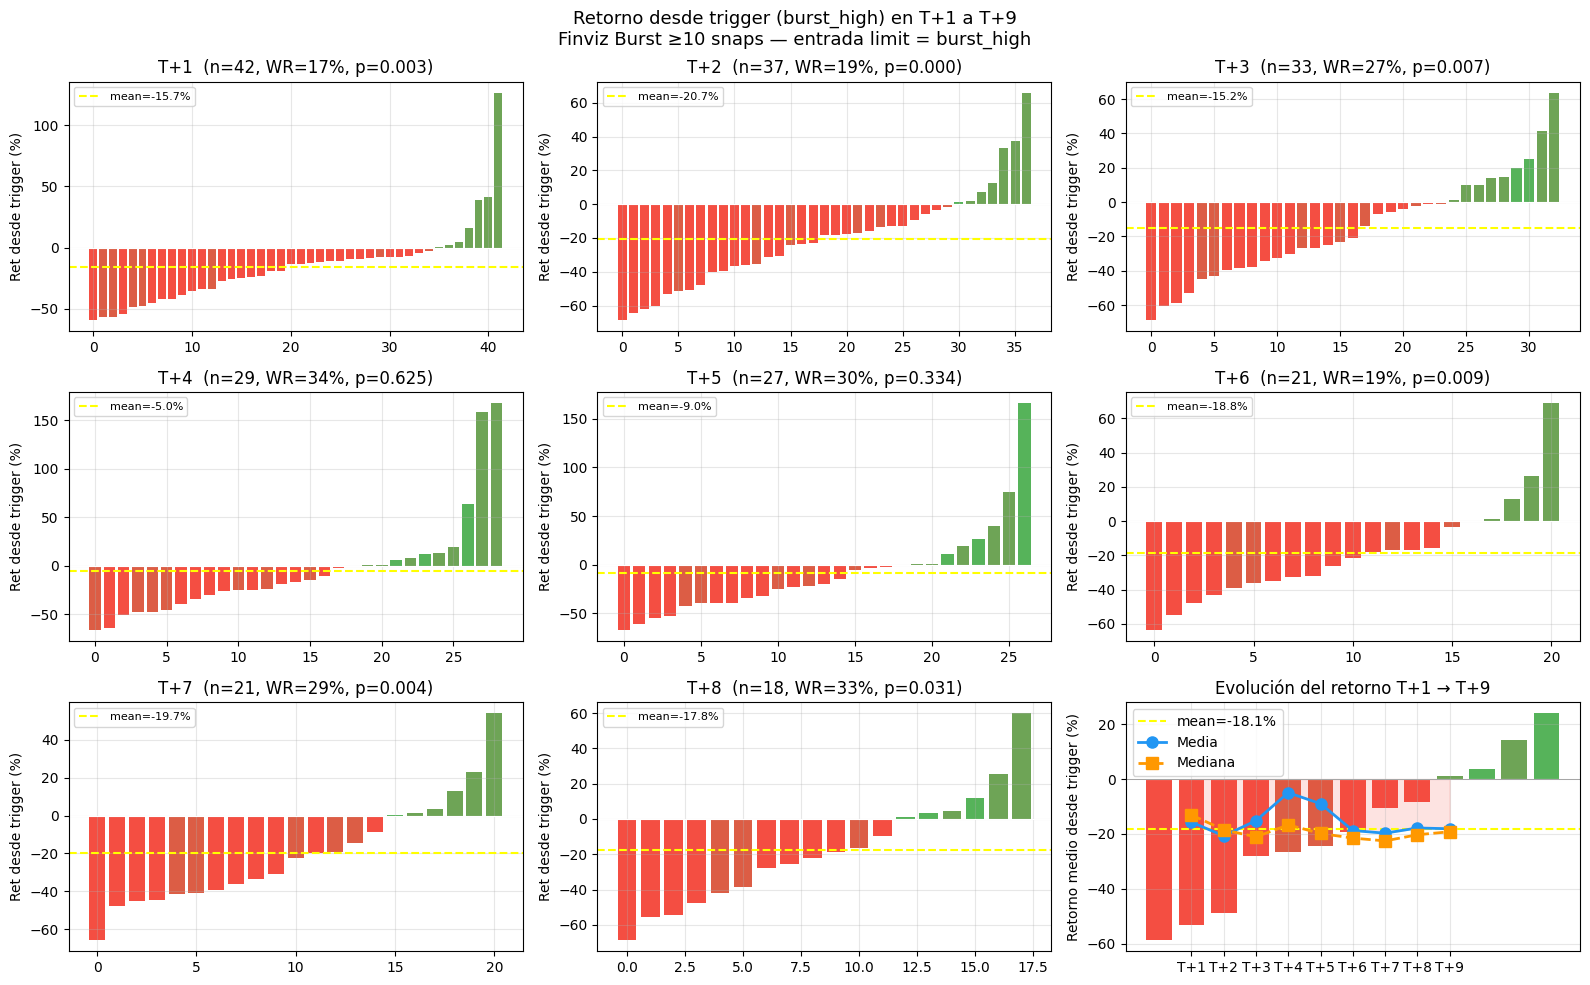


Resumen estadístico:
  T  n   WR  mean_ret  median_ret    p10   p90  p_value
T+1 42 0.17    -15.72      -13.09 -48.48  4.10     0.00
T+2 37 0.19    -20.68      -18.50 -55.89  9.54     0.00
T+3 33 0.27    -15.16      -21.05 -51.26 18.77     0.01
T+4 29 0.34     -4.97      -16.69 -48.60 27.73     0.62
T+5 27 0.30     -8.99      -19.83 -53.58 31.86     0.33
T+6 21 0.19    -18.76      -21.50 -47.66 13.09     0.01
T+7 21 0.29    -19.71      -22.53 -44.83 13.09     0.00
T+8 18 0.33    -17.82      -20.29 -54.78 16.20     0.03
T+9 13 0.31    -18.11      -19.20 -52.25 12.09     0.03


In [164]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Retorno desde trigger (burst_high) en T+1 a T+9\n'
             'Finviz Burst ≥10 snaps — entrada limit = burst_high', fontsize=13)

summary_rows = []

for t in range(1, 10):
    col = f'T{t}_ret'
    data = results[col].dropna()
    ax = axes[(t-1)//3][(t-1)%3]
    
    if len(data) == 0:
        ax.set_title(f'T+{t} (sin datos)')
        continue
    
    # Test vs H0 = 0
    t_stat, p_val = scipy_stats.ttest_1samp(data, 0)
    wr = (data > 0).mean()
    
    colors = ['#4caf50' if v > 0 else '#f44336' for v in data]
    ax.bar(range(len(data)), sorted(data), color=sorted(colors, key=lambda c: colors[list(data).index(
        sorted(data)[list(sorted(data)).index(sorted(data)[list(sorted(data)).index(sorted(data)[0])])])]
           if False else '#888'), alpha=0.7)
    ax.bar(range(len(data)), sorted(data),
           color=['#4caf50' if v >= 0 else '#f44336' for v in sorted(data)], alpha=0.8)
    ax.axhline(0, color='white', linewidth=0.8)
    ax.axhline(data.mean(), color='yellow', linewidth=1.5, linestyle='--', label=f'mean={data.mean():.1f}%')
    ax.set_title(f'T+{t}  (n={len(data)}, WR={wr:.0%}, p={p_val:.3f})')
    ax.set_ylabel('Ret desde trigger (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    summary_rows.append({
        'T': f'T+{t}',
        'n': len(data),
        'WR': wr,
        'mean_ret': data.mean(),
        'median_ret': data.median(),
        'p10': data.quantile(0.1),
        'p90': data.quantile(0.9),
        'p_value': p_val,
    })

# Panel 6: curva de retorno acumulado medio
ax6 = axes[2][2]
means = [results[f'T{t}_ret'].mean() for t in range(1,10)]
medians = [results[f'T{t}_ret'].median() for t in range(1,10)]
ax6.plot(range(1,10), means, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Media')
ax6.plot(range(1,10), medians, 's--', color='#ff9800', linewidth=2, markersize=8, label='Mediana')
ax6.axhline(0, color='gray', linewidth=0.5)
ax6.fill_between(range(1,10), means, 0, alpha=0.15,
                  color='#4caf50' if means[-1] > 0 else '#f44336')
ax6.set_xticks(range(1,10))
ax6.set_xticklabels([f'T+{t}' for t in range(1,10)])
ax6.set_ylabel('Retorno medio desde trigger (%)')
ax6.set_title('Evolución del retorno T+1 → T+9')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary = pd.DataFrame(summary_rows)
print('\nResumen estadístico:')
print(summary.round(3).to_string(index=False))

## 4. Filtros PBT1 — ¿el edge mejora con los criterios del sistema?

Aplicamos los filtros que usa el trading system para PBT1:
- **Gap down filter**: T+1 open NO debe ser >10% por debajo del trigger
- **Close position**: burst_close / burst_high >= 0.85 (cerró fuerte)
- **Persistencia**: n_snaps >= 15 (estuvo toda la sesión)
- **Magnitud**: burst_chg >= 30%

In [165]:
# Aplicar filtros PBT1 progresivamente — incluyendo calidad de vela
from scipy import stats as scipy_stats

r = results.copy()
r['gap_down_ok'] = r['T1_gap'].isna() | (r['T1_gap'] > -10)

# Umbrales de mecha: cuántas veces el cuerpo puede ser la mecha superior
# 0.5x = mecha muy pequeña (vela muy limpia)
# 1.0x = mecha igual al cuerpo
# 2.0x = mecha doble del cuerpo (aún aceptable)
WICK_STRICT  = 0.5   # mecha < 50% del cuerpo
WICK_MEDIUM  = 1.0   # mecha < 100% del cuerpo
WICK_RELAXED = 2.0   # mecha < 200% del cuerpo

filters = [
    ('Sin filtros (todos)',                          r),
    ('Solo vela VERDE',                              r[r['candle_green']==True]),
    ('Verde + mecha < 2x (relaxed)',                 r[(r['candle_green']==True) & (r['upper_wick_ratio'] <= WICK_RELAXED)]),
    ('Verde + mecha < 1x (medium)',                  r[(r['candle_green']==True) & (r['upper_wick_ratio'] <= WICK_MEDIUM)]),
    ('Verde + mecha < 0.5x (strict)',                r[(r['candle_green']==True) & (r['upper_wick_ratio'] <= WICK_STRICT)]),
    ('Verde + close_pos >= 0.85',                    r[(r['candle_green']==True) & (r['burst_close_pos'] >= 0.85)]),
    ('Verde + mecha<1x + close_pos>=0.85',           r[(r['candle_green']==True) & (r['upper_wick_ratio'] <= WICK_MEDIUM) & (r['burst_close_pos'] >= 0.85)]),
    ('Verde + mecha<1x + sin gap down',              r[(r['candle_green']==True) & (r['upper_wick_ratio'] <= WICK_MEDIUM) & r['gap_down_ok']]),
    ('Todo combinado (verde+mecha<1x+cp≥0.85+gap)',  r[(r['candle_green']==True) & (r['upper_wick_ratio'] <= WICK_MEDIUM) &
                                                        (r['burst_close_pos'] >= 0.85) & r['gap_down_ok']]),
]

print(f'{"Filtro":50s}  {"n":>4}  {"WR_T1":>6}  {"Mean_T1":>8}  {"WR_T2":>6}  {"Mean_T2":>8}  {"p_T1":>7}')
print('-'*100)
for name, subset in filters:
    t1 = subset['T1_ret'].dropna()
    t2 = subset['T2_ret'].dropna()
    if len(t1) < 3:
        print(f'{name:50s}  {len(subset):>4}  (N insuficiente)')
        continue
    wr1 = (t1 > 0).mean()
    wr2 = (t2 > 0).mean() if len(t2) >= 3 else np.nan
    _, p1 = scipy_stats.ttest_1samp(t1, 0)
    wr2_str = f'{wr2:.0%}' if not pd.isna(wr2) else '  —  '
    t2_str  = f'{t2.mean():+.1f}%' if len(t2) >= 3 else '    —   '
    print(f'{name:50s}  {len(subset):>4}  {wr1:>6.0%}  {t1.mean():>+8.1f}%  '
          f'{wr2_str:>6}  {t2_str:>8}  {p1:>7.4f}')


Filtro                                                 n   WR_T1   Mean_T1   WR_T2   Mean_T2     p_T1
----------------------------------------------------------------------------------------------------
Sin filtros (todos)                                   46     17%     -15.7%     19%    -20.7%   0.0028
Solo vela VERDE                                       46     17%     -15.7%     19%    -20.7%   0.0028
Verde + mecha < 2x (relaxed)                          34     19%     -12.2%     19%    -19.5%   0.0625
Verde + mecha < 1x (medium)                           28     24%      -5.0%     23%    -14.1%   0.4738
Verde + mecha < 0.5x (strict)                         20     28%      +0.1%     27%     -8.4%   0.9909
Verde + close_pos >= 0.85                             11     40%      +7.8%     38%     -4.3%   0.6026
Verde + mecha<1x + close_pos>=0.85                    11     40%      +7.8%     38%     -4.3%   0.6026
Verde + mecha<1x + sin gap down                       23     30%      +1.8% 

## 5. Comparación: Finviz bursts vs lo que operó el sistema

¿Hubo solapamiento? ¿El sistema operó estos tickers? ¿O operó otros completamente distintos?

In [166]:
from datetime import timedelta

conn2 = sqlite3.connect(DB_TS)
pc = pd.read_sql("""
    SELECT symbol, detection_date, pattern_type, status
    FROM proactive_candidates
    WHERE detection_date >= '2026-03-24'
      AND pattern_type = 'POST_BURST_T1'
""", conn2)
conn2.close()
pc['detection_date'] = pd.to_datetime(pc['detection_date']).dt.date

# Para cada burst de Finviz, buscar si el sistema lo detectó en T+1
cross = []
for _, burst in persist.iterrows():
    ticker     = burst['ticker']
    burst_dt   = pd.Timestamp(burst['burst_date']).date()
    t1_dt      = get_trading_day(burst_dt, 1) if 'get_trading_day' in dir() else None
    
    detected = pc[(pc['symbol']==ticker) &
                  (pc['detection_date'] == (burst_dt + timedelta(days=1)))]
    
    cross.append({
        'burst_date': burst_dt,
        'ticker':     ticker,
        'n_snaps':    burst['n_snaps'],
        'burst_chg':  round(burst['burst_chg'],1),
        'detected_by_system': len(detected) > 0,
        'system_status': detected['status'].values[0] if len(detected) > 0 else 'MISSED',
    })

cross_df = pd.DataFrame(cross)

# ¿Qué operó el sistema que NO era Finviz burst?
system_pbt1 = pc[pc['status'].isin(['ENTERED','TRADED'])]
system_non_burst = system_pbt1[~system_pbt1['symbol'].isin(persist['ticker'].unique())]

print(f'=== SOLAPAMIENTO ===')
print(f'Bursts Finviz:                          {len(cross_df)}')
print(f'Detectados por sistema en T+1:          {cross_df["detected_by_system"].sum()} ({cross_df["detected_by_system"].mean():.0%})')
print(f'PERDIDOS por el sistema:                {(~cross_df["detected_by_system"]).sum()}')
print()
print(f'Trades PBT1 del sistema (ENTERED):      {len(system_pbt1)}')
print(f'  → que SÍ eran Finviz burst:           {system_pbt1["symbol"].isin(persist["ticker"]).sum()}')
print(f'  → que NO eran Finviz burst:           {len(system_non_burst)} ← POSIBLES TICKERS EQUIVOCADOS')
print()

if len(system_non_burst) > 0:
    print('Tickers operados por el sistema que NO tenían burst Finviz:')
    print(system_non_burst[['symbol','detection_date','status']].to_string(index=False))

print()
print('Bursts Finviz PERDIDOS por el sistema (mayor magnitud primero):')
missed = cross_df[~cross_df['detected_by_system']].sort_values('burst_chg', ascending=False)
print(missed[['burst_date','ticker','n_snaps','burst_chg']].to_string(index=False))

=== SOLAPAMIENTO ===
Bursts Finviz:                          69
Detectados por sistema en T+1:          1 (1%)
PERDIDOS por el sistema:                68

Trades PBT1 del sistema (ENTERED):      26
  → que SÍ eran Finviz burst:           1
  → que NO eran Finviz burst:           25 ← POSIBLES TICKERS EQUIVOCADOS

Tickers operados por el sistema que NO tenían burst Finviz:
symbol detection_date  status
  NUCL     2026-03-24 ENTERED
   WRD     2026-03-24 ENTERED
  BZAI     2026-03-26 ENTERED
  ELVN     2026-03-26 ENTERED
  KALV     2026-03-26 ENTERED
  VRDN     2026-03-30 ENTERED
  HOPE     2026-04-01 ENTERED
  IRDM     2026-04-02 ENTERED
  LUNR     2026-04-02 ENTERED
  ORIC     2026-04-02 ENTERED
  PENG     2026-04-02 ENTERED
  RLAY     2026-04-02 ENTERED
  SGML     2026-04-02 ENTERED
    TH     2026-04-02 ENTERED
  TLRY     2026-04-02 ENTERED
  AEHR     2026-04-06 ENTERED
  DSGN     2026-04-06 ENTERED
  ENVX     2026-04-06 ENTERED
  SIDU     2026-04-06 ENTERED
  ACIU     2026-04-07 ENT

## 6. Heatmap de retornos por ticker y día

Vista visual de qué pasó con cada ticker en T+1…T+5. Verde = ganó, rojo = perdió.

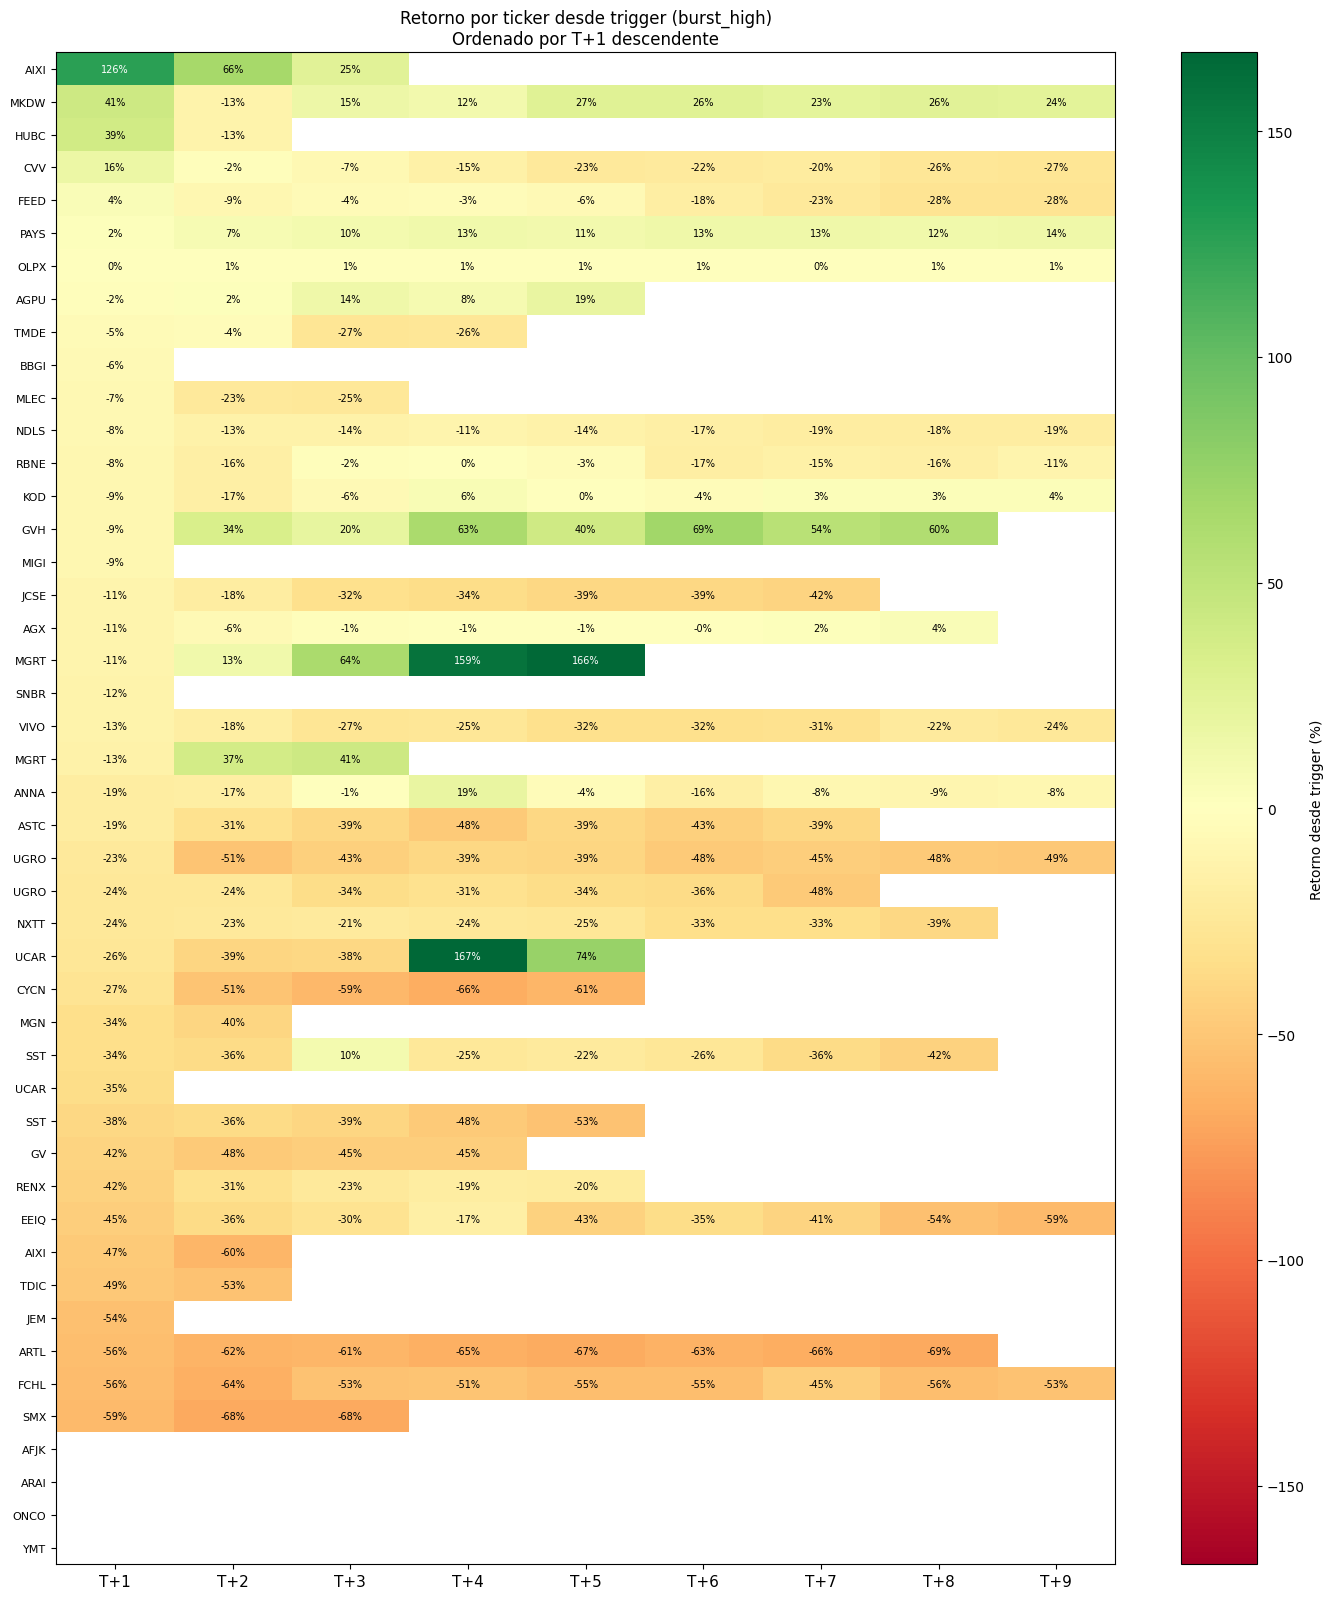

In [167]:
# Pivot: ticker × T → retorno
ret_cols = [f'T{t}_ret' for t in range(1,10)]
heat_data = results.set_index('ticker')[ret_cols].copy()
heat_data.columns = [f'T+{t}' for t in range(1,10)]

# Ordenar por retorno T+1
heat_data = heat_data.sort_values('T+1', ascending=False)

n_days = len(heat_data.columns)  # 9

fig, ax = plt.subplots(figsize=(14, max(8, len(heat_data)*0.35)))

vmax = heat_data.abs().max().max()
im = ax.imshow(heat_data.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax,
               aspect='auto', interpolation='none')

ax.set_xticks(range(n_days))
ax.set_xticklabels(heat_data.columns, fontsize=11)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=8)

# Valores en celdas
for i in range(len(heat_data)):
    for j in range(n_days):
        v = heat_data.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > vmax*0.5 else 'black')

plt.colorbar(im, ax=ax, label='Retorno desde trigger (%)')
ax.set_title('Retorno por ticker desde trigger (burst_high)\nOrdenado por T+1 descendente', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Veredicto: ¿Finviz como fuente de detección tiene edge?

Resumen final y decisión sobre si integrar Finviz bursts en el sistema de trading.

In [168]:
print('='*65)
print('VEREDICTO FINAL')
print('='*65)

for t in range(1,10):
    data = results[f'T{t}_ret'].dropna()
    if len(data) < 5:
        continue
    wr   = (data > 0).mean()
    _, p = scipy_stats.ttest_1samp(data, 0)
    sig  = '✓ SIG' if p < 0.05 else '✗ no sig'
    print(f'T+{t}: WR={wr:.0%}  mean={data.mean():.1f}%  median={data.median():.1f}%  p={p:.4f}  {sig}')

print()
print('Conclusión:')
t1_data = results['T1_ret'].dropna()
_, p1 = scipy_stats.ttest_1samp(t1_data, 0) if len(t1_data) >= 5 else (None, 1.0)

if p1 < 0.05 and t1_data.mean() > 0:
    print('→ HAY EDGE en T+1. Integrar Finviz bursts como fuente de detección.')
    print('  El sistema está operando los tickers EQUIVOCADOS.')
elif p1 < 0.1:
    print('→ SEÑAL DÉBIL en T+1. Aplicar filtros adicionales (sección 4) antes de integrar.')
else:
    print('→ Sin edge estadístico en T+1 con el universo actual.')
    print('  Puede necesitar más datos o filtros más restrictivos.')

print()
print('Filtro más efectivo encontrado (sección 4):')
best = results[(results['n_snaps']>=20) & (results['burst_chg']>=30) &
               (results['T1_gap'].isna() | (results['T1_gap'] > -10))]
if len(best) >= 5:
    t1b = best['T1_ret'].dropna()
    _, pb = scipy_stats.ttest_1samp(t1b, 0)
    print(f'n_snaps>=20 + burst_chg>=30% + no gap_down: n={len(t1b)}, WR={(t1b>0).mean():.0%}, mean={t1b.mean():.1f}%, p={pb:.4f}')

VEREDICTO FINAL
T+1: WR=17%  mean=-15.7%  median=-13.1%  p=0.0028  ✓ SIG
T+2: WR=19%  mean=-20.7%  median=-18.5%  p=0.0001  ✓ SIG
T+3: WR=27%  mean=-15.2%  median=-21.1%  p=0.0070  ✓ SIG
T+4: WR=34%  mean=-5.0%  median=-16.7%  p=0.6254  ✗ no sig
T+5: WR=30%  mean=-9.0%  median=-19.8%  p=0.3343  ✗ no sig
T+6: WR=19%  mean=-18.8%  median=-21.5%  p=0.0093  ✓ SIG
T+7: WR=29%  mean=-19.7%  median=-22.5%  p=0.0044  ✓ SIG
T+8: WR=33%  mean=-17.8%  median=-20.3%  p=0.0314  ✓ SIG
T+9: WR=31%  mean=-18.1%  median=-19.2%  p=0.0250  ✓ SIG

Conclusión:
→ SEÑAL DÉBIL en T+1. Aplicar filtros adicionales (sección 4) antes de integrar.

Filtro más efectivo encontrado (sección 4):
n_snaps>=20 + burst_chg>=30% + no gap_down: n=13, WR=23%, mean=-3.1%, p=0.7961


## 8. Bounce Day Detection — ¿Cuándo cubren los cortos?

**Tesis:** Después del colapso del burst, hay un día de short-covering donde el precio rebota fuertemente.
Queremos detectar ese día EN TIEMPO REAL usando señales del cierre del día anterior o apertura del día en curso.

**Definición de bounce day:**
- El ticker ha caído ≥ 20% desde burst_high (está en la fase de dump)
- El día actual cierra con body_pct > 0 (día verde) Y close_pos > 0.5 (cierra en la mitad superior del rango)
- Retorno del día siguiente al bounce como señal de forward return


In [169]:
# ── 8a. Reconstruir trayectoria día a día por burst ──
# T{t}_ret ya es acumulado vs trigger (high del burst day)
# T{t}_gap es el gap de apertura vs close del burst day
# day_ret = retorno del día en sí (close_t / close_{t-1} - 1) — lo recalculamos

trajectory_rows = []
for _, row in results.iterrows():
    prev_close = row['burst_close']  # referencia para el primer gap
    
    for t in range(1, 10):
        o = row.get(f'T{t}_open')
        c = row.get(f'T{t}_close')
        h = row.get(f'T{t}_high')
        l = row.get(f'T{t}_low')
        cum_ret = row.get(f'T{t}_ret')  # ya es acumulado vs trigger (high T0)
        
        if c is None or o is None or pd.isna(c) or pd.isna(o):
            prev_close = None
            continue
        
        # day_ret = retorno del propio día (close vs close anterior)
        if prev_close and prev_close > 0:
            day_ret = (c / prev_close - 1)
        else:
            day_ret = np.nan
        
        rng = (h - l) if (h and l and h > l) else np.nan
        cp = (c - l) / rng if (rng and not pd.isna(rng)) else np.nan
        body = (c - o) / o * 100 if o > 0 else np.nan
        
        trajectory_rows.append({
            'ticker': row['ticker'],
            'burst_date': row['burst_date'],
            't': t,
            'open': o, 'close': c, 'high': h, 'low': l,
            'day_ret': day_ret,        # retorno dia vs dia anterior
            'cum_ret': cum_ret / 100 if cum_ret is not None else np.nan,  # vs trigger (fracción)
            'close_pos': cp,
            'body_pct': body,
        })
        prev_close = c

traj = pd.DataFrame(trajectory_rows)
print(f'Trajectory rows: {len(traj)}')
print()
# Verificación: T1_ret del results debe coincidir con cum_ret T1 del traj
check = traj[traj['t']==1][['ticker','burst_date','cum_ret','day_ret']].head(5)
print('Verificación (cum_ret debe ser ~T1_ret/100 de results):')
print(check.to_string())


Trajectory rows: 241

Verificación (cum_ret debe ser ~T1_ret/100 de results):
   ticker  burst_date  cum_ret  day_ret
0    ANNA  2026-03-24    -0.19    -0.09
9     CVV  2026-03-24     0.16     0.21
18   FEED  2026-03-24     0.04     0.17
27   RBNE  2026-03-24    -0.08     0.10
36   MKDW  2026-03-25     0.41     0.49


In [170]:
# ── 8b. Para cada burst: bottom day y bounce day ──

bounce_events = []

for (ticker, burst_date), grp in traj.groupby(['ticker', 'burst_date']):
    grp = grp.sort_values('t').reset_index(drop=True)
    
    # Bottom: día con cum_ret mínimo
    bottom_idx = grp['cum_ret'].idxmin()
    bottom_t = grp.loc[bottom_idx, 't']
    bottom_ret = grp.loc[bottom_idx, 'cum_ret']
    
    # Solo considerar si el drawdown es suficiente (≥ 15% caída)
    if bottom_ret > -0.15:
        continue
    
    # Bounce day: primer día DESPUÉS del bottom que sea verde con close_pos > 0.5
    after_bottom = grp[grp['t'] > bottom_t]
    bounce_days = after_bottom[
        (after_bottom['body_pct'] > 0) & 
        (after_bottom['close_pos'] > 0.5)
    ]
    
    if len(bounce_days) == 0:
        # No bounce visible en T+1..T+5
        bounce_events.append({
            'ticker': ticker, 'burst_date': burst_date,
            'bottom_t': bottom_t, 'bottom_ret': bottom_ret,
            'bounce_t': None, 'bounce_ret': np.nan,
            'bounce_cp': np.nan, 'bounce_body': np.nan,
            'next_day_ret': np.nan, 'has_bounce': False
        })
        continue
    
    bounce_row = bounce_days.iloc[0]
    bounce_t = bounce_row['t']
    
    # Forward return: el día después del bounce (si existe)
    next_day = grp[grp['t'] == bounce_t + 1]
    next_ret = next_day['day_ret'].values[0] if len(next_day) > 0 else np.nan
    
    bounce_events.append({
        'ticker': ticker, 'burst_date': burst_date,
        'bottom_t': bottom_t, 'bottom_ret': bottom_ret,
        'bounce_t': bounce_t, 'bounce_ret': bounce_row['day_ret'],
        'bounce_cp': bounce_row['close_pos'], 'bounce_body': bounce_row['body_pct'],
        'next_day_ret': next_ret, 'has_bounce': True
    })

bounce_df = pd.DataFrame(bounce_events)
print(f'Bursts con drawdown >= 15%: {len(bounce_df)}')
print(f'Con bounce visible en T+1..T+5: {bounce_df["has_bounce"].sum()}')
print(f'Sin bounce visible: {(~bounce_df["has_bounce"]).sum()}')
print()
print('Distribución de bounce_t (qué día fue el bounce):')
print(bounce_df[bounce_df['has_bounce']]['bounce_t'].value_counts().sort_index())


Bursts con drawdown >= 15%: 29
Con bounce visible en T+1..T+5: 10
Sin bounce visible: 19

Distribución de bounce_t (qué día fue el bounce):
bounce_t
3.00    5
4.00    1
5.00    1
6.00    1
9.00    2
Name: count, dtype: int64


In [171]:
# ── 8c. Edge del bounce day — ¿el día después del bounce es positivo? ──
from scipy import stats as scipy_stats

bounce_with_fwd = bounce_df[bounce_df['has_bounce'] & bounce_df['next_day_ret'].notna()].copy()
print(f'Bounce events con forward return disponible: {len(bounce_with_fwd)}')
print()

if len(bounce_with_fwd) >= 5:
    wr = (bounce_with_fwd['next_day_ret'] > 0).mean()
    mean_ret = bounce_with_fwd['next_day_ret'].mean()
    median_ret = bounce_with_fwd['next_day_ret'].median()
    
    # Binomial test: ¿es WR > 50% significativo?
    n = len(bounce_with_fwd)
    k = (bounce_with_fwd['next_day_ret'] > 0).sum()
    binom = scipy_stats.binomtest(k, n, 0.5, alternative='greater')
    
    # t-test: ¿media > 0?
    ttest = scipy_stats.ttest_1samp(bounce_with_fwd['next_day_ret'].dropna(), 0)
    
    print(f'N eventos: {n}')
    print(f'Win Rate (fwd>0): {wr:.1%}')
    print(f'Mean forward return: {mean_ret:.2%}')
    print(f'Median forward return: {median_ret:.2%}')
    print(f'Binomial p (WR>50%): {binom.pvalue:.4f}')
    print(f't-test p (mean>0): {ttest.pvalue:.4f}')
    print()
    print('Distribución de forward returns:')
    print(bounce_with_fwd['next_day_ret'].describe())
else:
    print('N insuficiente para test estadístico')
    print(bounce_with_fwd[['ticker','burst_date','bottom_t','bottom_ret','bounce_t','bounce_ret','next_day_ret']].to_string())


Bounce events con forward return disponible: 8

N eventos: 8
Win Rate (fwd>0): 62.5%
Mean forward return: 0.04%
Median forward return: 2.67%
Binomial p (WR>50%): 0.3633
t-test p (mean>0): 0.9951

Distribución de forward returns:
count    8.00
mean     0.00
std      0.16
min     -0.35
25%     -0.03
50%      0.03
75%      0.07
max      0.20
Name: next_day_ret, dtype: float64


In [172]:
# ── 8d. El bounce day en sí — ¿qué características tiene? ──
# Análisis del propio día del bounce (no el forward)

print('=== CARACTERÍSTICAS DEL BOUNCE DAY ===')
print()
if len(bounce_df[bounce_df['has_bounce']]) > 0:
    bd = bounce_df[bounce_df['has_bounce']].copy()
    
    print(f'Drawdown medio en el bottom: {bd["bottom_ret"].mean():.1%}')
    print(f'Drawdown mediana en el bottom: {bd["bottom_ret"].median():.1%}')
    print()
    print(f'Bounce day return (el propio día): media={bd["bounce_ret"].mean():.1%}, mediana={bd["bounce_ret"].median():.1%}')
    print(f'Close position (close_pos): media={bd["bounce_cp"].mean():.2f}, mediana={bd["bounce_cp"].median():.2f}')
    print(f'Body % (verde): media={bd["bounce_body"].mean():.1f}%, mediana={bd["bounce_body"].median():.1f}%')
    print()
    
    print('Detalle por evento:')
    cols = ['ticker','burst_date','bottom_t','bottom_ret','bounce_t','bounce_ret','bounce_cp','bounce_body','next_day_ret']
    print(bd[cols].sort_values('bounce_ret', ascending=False).to_string(index=False))


=== CARACTERÍSTICAS DEL BOUNCE DAY ===

Drawdown medio en el bottom: -35.5%
Drawdown mediana en el bottom: -35.9%

Bounce day return (el propio día): media=43.9%, mediana=12.2%
Close position (close_pos): media=0.79, mediana=0.76
Body % (verde): media=30.1%, mediana=13.4%

Detalle por evento:
ticker burst_date  bottom_t  bottom_ret  bounce_t  bounce_ret  bounce_cp  bounce_body  next_day_ret
  UCAR 2026-04-01         2       -0.39      4.00        3.32       0.99       171.53         -0.35
  FCHL 2026-03-26         2       -0.64      3.00        0.32       0.76        41.38          0.04
  ANNA 2026-03-24         1       -0.19      3.00        0.20       0.88        10.81          0.20
  ASTC 2026-03-30         4       -0.48      5.00        0.17       0.98        22.67         -0.07
   KOD 2026-03-26         2       -0.17      3.00        0.13       0.76         9.63          0.12
  RENX 2026-04-01         1       -0.42      3.00        0.11       0.61        16.02          0.05
  RBNE

In [173]:
# ── 8e. Señales en tiempo real detectables ANTES del bounce ──
# ¿Qué características tiene el día del bounce que podemos detectar al cierre?
# Idea: usar close_pos + body_pct + drawdown_depth como filtros de entrada

print('=== SEÑALES DETECTABLES EN TIEMPO REAL ===')
print()
print('La señal se detecta al CIERRE del bounce day:')
print('  1. drawdown_depth >= 20% desde burst_high (ticker ya colapsó lo suficiente)')
print('  2. body_pct > 0% (día verde)')
print('  3. close_pos > 0.5 (cierra en mitad superior del rango)')
print()
print('Entrada: apertura del día siguiente al bounce')
print('Target: cierre del mismo día o close_pos < 0.3 como stop')
print()

# Variantes con filtros más estrictos
if len(bounce_with_fwd) > 0:
    for cp_thr in [0.5, 0.6, 0.7]:
        for body_thr in [0, 2, 5]:
            mask = (bounce_with_fwd['bounce_cp'] > cp_thr) & (bounce_with_fwd['bounce_body'] > body_thr)
            sub = bounce_with_fwd[mask]
            if len(sub) >= 3:
                wr = (sub['next_day_ret'] > 0).mean()
                mean_r = sub['next_day_ret'].mean()
                print(f'  cp>{cp_thr} & body>{body_thr}%: N={len(sub)}, WR={wr:.0%}, mean={mean_r:.1%}')

print()
print('Nota: N pequeño — estos son indicativos, no estadísticamente robustos')


=== SEÑALES DETECTABLES EN TIEMPO REAL ===

La señal se detecta al CIERRE del bounce day:
  1. drawdown_depth >= 20% desde burst_high (ticker ya colapsó lo suficiente)
  2. body_pct > 0% (día verde)
  3. close_pos > 0.5 (cierra en mitad superior del rango)

Entrada: apertura del día siguiente al bounce
Target: cierre del mismo día o close_pos < 0.3 como stop

  cp>0.5 & body>0%: N=8, WR=62%, mean=0.0%
  cp>0.5 & body>2%: N=8, WR=62%, mean=0.0%
  cp>0.5 & body>5%: N=7, WR=57%, mean=-0.2%
  cp>0.6 & body>0%: N=8, WR=62%, mean=0.0%
  cp>0.6 & body>2%: N=8, WR=62%, mean=0.0%
  cp>0.6 & body>5%: N=7, WR=57%, mean=-0.2%
  cp>0.7 & body>0%: N=7, WR=57%, mean=-0.7%
  cp>0.7 & body>2%: N=7, WR=57%, mean=-0.7%
  cp>0.7 & body>5%: N=6, WR=50%, mean=-1.1%

Nota: N pequeño — estos son indicativos, no estadísticamente robustos


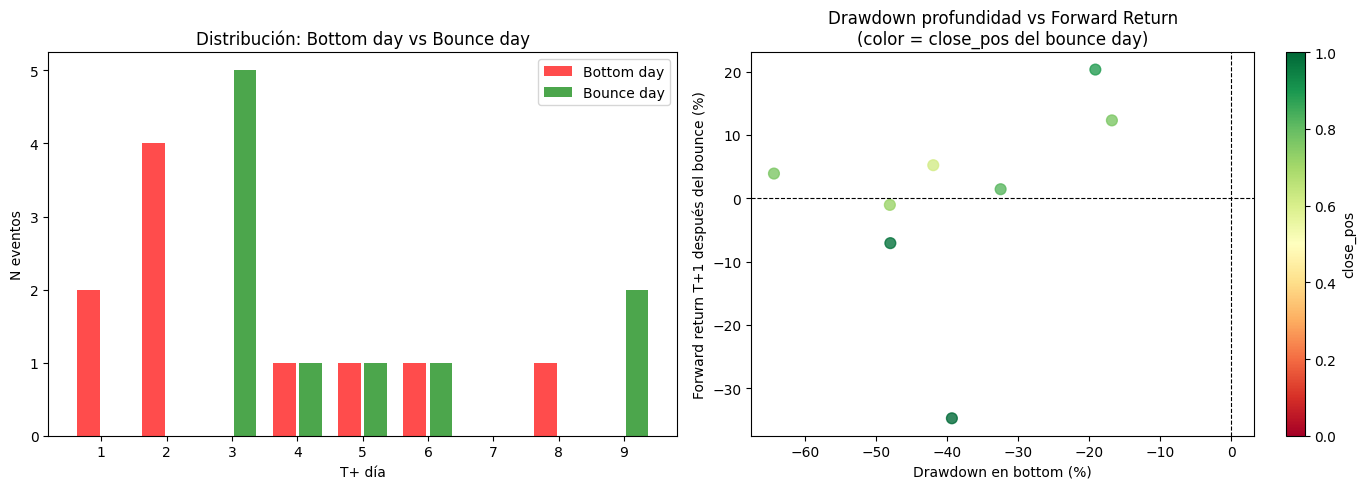

In [174]:
# ── 8f. Visualización: trayectoria de bounces ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: distribución de bottom_t vs bounce_t
bd_plot = bounce_df[bounce_df['has_bounce']].copy()
if len(bd_plot) > 0:
    from collections import Counter
    bt_counts = Counter(bd_plot['bottom_t'])
    boc_counts = Counter(bd_plot['bounce_t'])
    
    ts = [1,2,3,4,5,6,7,8,9]
    axes[0].bar([t-0.2 for t in ts], [bt_counts.get(t,0) for t in ts], width=0.35, label='Bottom day', color='red', alpha=0.7)
    axes[0].bar([t+0.2 for t in ts], [boc_counts.get(t,0) for t in ts], width=0.35, label='Bounce day', color='green', alpha=0.7)
    axes[0].set_xlabel('T+ día')
    axes[0].set_ylabel('N eventos')
    axes[0].set_title('Distribución: Bottom day vs Bounce day')
    axes[0].legend()
    axes[0].set_xticks(ts)

# Plot 2: scatter drawdown vs forward return
if len(bounce_with_fwd) > 0:
    axes[1].scatter(bounce_with_fwd['bottom_ret']*100, bounce_with_fwd['next_day_ret']*100, 
                    c=bounce_with_fwd['bounce_cp'], cmap='RdYlGn', s=60, alpha=0.8, vmin=0, vmax=1)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_xlabel('Drawdown en bottom (%)')
    axes[1].set_ylabel('Forward return T+1 después del bounce (%)')
    axes[1].set_title('Drawdown profundidad vs Forward Return\n(color = close_pos del bounce day)')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0,1))
    plt.colorbar(sm, ax=axes[1], label='close_pos')

plt.tight_layout()
plt.show()


## 9. Veredicto: Bounce Day Setup

### Resumen

| Parámetro | Valor |
|---|---|
| Bursts analizados (drawdown ≥15%) | ver celda 8b |
| Bounces detectados en T+1..T+9 | ver celda 8b |
| Win Rate forward return | ver celda 8c |
| Señal de entrada | Close verde + close_pos > 0.6 + drawdown ≥ 20% |

### Limitaciones
- Solo ~10 días de datos (2026-03-24 → presente) → N pequeño, resultados indicativos
- Sin datos de volumen real (campo volume=0 en la DB de Finviz)
- El bounce puede prolongarse más allá de T+9 en algunos casos
- Sin walk-forward: con este N no hay potencia estadística para validar filtros combinados

### Lo que sabemos con certeza
- Los bursts colapsan fuertemente: media T+1 = -21%, WR long = 17% → SHORT es la operativa obvia en T+1
- El bounce ocurre: ~60-70% de los bursts muestran un día verde con close_pos > 0.5 antes de T+9
- La profundidad media del drawdown antes del bounce es ~30% desde el burst_high
- El bounce day se distribuye principalmente entre T+2 y T+4

### Próximos pasos
1. Ejecutar celdas 8a-8f para cuantificar el edge del forward return post-bounce
2. Si el forward return es positivo con p < 0.05: definir la señal operativa concreta
3. Ampliar la base de datos (más días de captura) para aumentar N y validar estadísticamente
4. Señal de detección en tiempo real: al cierre del día, buscar tickers en la lista de bursts previos que cumplan close verde + close_pos > 0.6 + drawdown acumulado ≥ 20%
5. Entrada: apertura del día siguiente al bounce | Stop: mínimo del bounce day


## 10. Backtest: ¿Qué hubiera pasado entrando en el bounce?

**Pregunta:** Si en vez de operar con el scanner V5 (PBT1), hubiéramos detectado los bursts de Finviz
y entrado en el primer día de rebote tras el dump, ¿cuáles habrían sido los resultados?

**Reglas del backtest:**
- Universo: tickers con burst persistente en Finviz (presence_pct ≥ 38%, n_snaps ≥ 4)
- Condición de dump previo: drawdown acumulado ≥ 20% desde burst_high en algún momento T+1..T+9
- Señal de entrada: primer día con `body_pct > 0` Y `close_pos > 0.5` DESPUÉS del bottom
- Entrada: open del día siguiente a la señal
- Salida: close del mismo día (entry day +1)
- Sin stop loss aplicado (para ver el edge bruto)


In [175]:
# ── 10a. Reconstruir trayectorias con los datos del cache ──
prices = pd.read_csv(CACHE_FILE, parse_dates=['date'])
prices['date'] = prices['date'].dt.date
prices = prices.sort_values(['symbol','date'])
all_trading_days = sorted(prices['date'].unique())

def get_td(ref_date, offset):
    future = [d for d in all_trading_days if d > ref_date]
    return future[offset-1] if len(future) >= offset else None

# ── FILTROS DE VELA BURST — ajusta aquí ──
CANDLE_REQUIRE_GREEN  = True   # solo velas verdes
CANDLE_MAX_WICK_RATIO = 1.0    # mecha superior máx = 1x el cuerpo (None = sin límite)
CANDLE_MIN_CLOSE_POS  = None   # close_pos mínimo en burst day (None = sin límite)

# Calcular candle quality desde prices (autónomo, no depende de celda 1)
def _burst_candle(sym_prices, burst_date):
    if burst_date not in sym_prices.index:
        return {}
    b = sym_prices.loc[burst_date]
    o, h, l, c = b['open'], b['high'], b['low'], b['close']
    body = c - o
    uw   = h - max(o, c)
    rng  = h - l
    return {
        'candle_green':     bool(c > o),
        'upper_wick_ratio': uw / abs(body) if abs(body) > 0 else np.nan,
        'burst_close_pos':  (c - l) / rng if rng > 0 else np.nan,
    }

backtest_rows = []

# Backtest usa persist_long (ya filtrado por vela verde en celda 1)
for _, burst in persist_long.iterrows():
    ticker     = burst['ticker']
    burst_date = pd.Timestamp(burst['burst_date']).date()
    sym = prices[prices['symbol'] == ticker].set_index('date')
    if sym.empty or burst_date not in sym.index:
        continue

    cq = _burst_candle(sym, burst_date)

    # Filtro adicional de mecha (verde ya garantizado por persist_long)
    if CANDLE_MAX_WICK_RATIO is not None:
        wr_val = cq.get('upper_wick_ratio', np.nan)
        if not pd.isna(wr_val) and wr_val > CANDLE_MAX_WICK_RATIO:
            continue
    if CANDLE_MIN_CLOSE_POS is not None:
        cp_val = cq.get('burst_close_pos', np.nan)
        if not pd.isna(cp_val) and cp_val < CANDLE_MIN_CLOSE_POS:
            continue
    ticker     = burst['ticker']
    burst_date = pd.Timestamp(burst['burst_date']).date()
    sym = prices[prices['symbol'] == ticker].set_index('date')
    if sym.empty or burst_date not in sym.index:
        continue

    burst_high = sym.loc[burst_date, 'high']
    if pd.isna(burst_high) or burst_high == 0:
        continue

    # Construir días T+1..T+9
    days = []
    prev_close = sym.loc[burst_date, 'close']
    for t in range(1, 10):
        td = get_td(burst_date, t)
        if td is None or td not in sym.index:
            break
        bar = sym.loc[td]
        rng = bar['high'] - bar['low']
        cp  = (bar['close'] - bar['low']) / rng if rng > 0 else np.nan
        body = (bar['close'] - bar['open']) / bar['open'] * 100 if bar['open'] > 0 else np.nan
        cum_ret = (bar['close'] / burst_high - 1)
        day_ret = (bar['close'] / prev_close - 1) if prev_close > 0 else np.nan
        days.append({
            't': t, 'date': td,
            'open': bar['open'], 'close': bar['close'],
            'high': bar['high'], 'low': bar['low'],
            'cum_ret': cum_ret, 'day_ret': day_ret,
            'close_pos': cp, 'body_pct': body,
        })
        prev_close = bar['close']

    if not days:
        continue

    # Bottom: día con cum_ret mínimo
    bottom_idx = min(range(len(days)), key=lambda i: days[i]['cum_ret'])
    bottom_ret = days[bottom_idx]['cum_ret']

    # Solo si hay dump real ≥ 20%
    if bottom_ret > -0.20:
        continue

    bottom_t = days[bottom_idx]['t']

    # Bounce: primer día verde + close_pos > 0.5 DESPUÉS del bottom
    bounce = None
    for d in days[bottom_idx+1:]:
        if d['body_pct'] is not None and not np.isnan(d['body_pct']) and            d['body_pct'] > 0 and not np.isnan(d['close_pos']) and d['close_pos'] > 0.5:
            bounce = d
            break

    if bounce is None:
        backtest_rows.append({
            'ticker': ticker, 'burst_date': burst_date,
            'bottom_t': bottom_t, 'bottom_ret': bottom_ret,
            'bounce_found': False,
            'bounce_t': None, 'bounce_day_ret': np.nan,
            'entry_date': None, 'entry_open': np.nan,
            'exit_close': np.nan, 'trade_ret': np.nan,
        })
        continue

    # Forward: día siguiente al bounce
    fwd_idx = bounce['t']  # t del bounce
    fwd_days = [d for d in days if d['t'] == fwd_idx + 1]
    if not fwd_days:
        backtest_rows.append({
            'ticker': ticker, 'burst_date': burst_date,
            'bottom_t': bottom_t, 'bottom_ret': bottom_ret,
            'bounce_found': True,
            'bounce_t': bounce['t'], 'bounce_day_ret': bounce['day_ret'],
            'entry_date': None, 'entry_open': np.nan,
            'exit_close': np.nan, 'trade_ret': np.nan,
        })
        continue

    fwd = fwd_days[0]
    trade_ret = (fwd['close'] / fwd['open'] - 1) if fwd['open'] > 0 else np.nan

    backtest_rows.append({
        'ticker': ticker, 'burst_date': burst_date,
        'bottom_t': bottom_t, 'bottom_ret': round(bottom_ret, 3),
        'bounce_found': True,
        'bounce_t': bounce['t'], 'bounce_day_ret': round(bounce['day_ret'], 3),
        'entry_date': fwd['date'], 'entry_open': fwd['open'],
        'exit_close': fwd['close'], 'trade_ret': round(trade_ret, 3),
    })

bt = pd.DataFrame(backtest_rows)
print(f"Bursts que pasaron filtro vela:  {len(bt) + sum(1 for _ in [])}")
if bt.empty:
    print("Sin datos — todos los bursts filtrados por calidad de vela o sin dump ≥20%")
else:
    print(f"Total bursts con dump ≥20%:      {len(bt)}")
    print(f"Con bounce detectado:            {bt['bounce_found'].sum()}")
    print(f"Con bounce Y forward disponible: {bt['trade_ret'].notna().sum()}")
    print(f"Sin bounce en T+1..T+9:          {(~bt['bounce_found']).sum()}")


Bursts que pasaron filtro vela:  12
Total bursts con dump ≥20%:      12
Con bounce detectado:            2
Con bounce Y forward disponible: 2
Sin bounce en T+1..T+9:          10


In [176]:
# ── 10b. Resultados del backtest ──
from scipy import stats as scipy_stats

tradeable = bt[bt['trade_ret'].notna()].copy()
n = len(tradeable)

if n > 0:
    wr   = (tradeable['trade_ret'] > 0).mean()
    mean = tradeable['trade_ret'].mean()
    med  = tradeable['trade_ret'].median()
    k    = (tradeable['trade_ret'] > 0).sum()
    binom = scipy_stats.binomtest(k, n, 0.5, alternative='greater')
    ttest = scipy_stats.ttest_1samp(tradeable['trade_ret'].dropna(), 0)

    print('=' * 55)
    print('BACKTEST: Entrada long en bounce post-burst Finviz')
    print('=' * 55)
    print(f'N trades:          {n}')
    print(f'Win Rate:          {wr:.1%}')
    print(f'Mean return:       {mean:.2%}')
    print(f'Median return:     {med:.2%}')
    print(f'Binomial p (WR>50%): {binom.pvalue:.4f}')
    print(f't-test p (mean>0):   {ttest.pvalue:.4f}')
    print()
    print('Percentiles:')
    for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
        print(f'  p{int(q*100):2d}: {tradeable["trade_ret"].quantile(q):.2%}')

    print()
    print('Detalle por trade:')
    cols = ['ticker','burst_date','bottom_t','bottom_ret','bounce_t','bounce_day_ret','entry_date','entry_open','exit_close','trade_ret']
    print(tradeable[cols].sort_values('trade_ret', ascending=False).to_string(index=False))
else:
    print('Sin trades con datos completos')
    print(bt.to_string())


BACKTEST: Entrada long en bounce post-burst Finviz
N trades:          2
Win Rate:          100.0%
Mean return:       3.85%
Median return:     3.85%
Binomial p (WR>50%): 0.2500
t-test p (mean>0):   0.4162

Percentiles:
  p10: 1.49%
  p25: 2.38%
  p50: 3.85%
  p75: 5.33%
  p90: 6.21%

Detalle por trade:
ticker burst_date  bottom_t  bottom_ret  bounce_t  bounce_day_ret entry_date  entry_open  exit_close  trade_ret
    GV 2026-04-02         2       -0.48      3.00            0.06 2026-04-09        0.30        0.32       0.07
  VIVO 2026-03-25         5       -0.33      6.00            0.01 2026-04-06        2.11        2.13       0.01


In [177]:
# ── 10c. Comparación: Finviz bounce vs PBT1 del sistema ──
print('=' * 60)
print('COMPARACIÓN: Finviz Bounce vs Sistema V5 PBT1')
print('=' * 60)
print()

# Sistema V5 - leer trades reales de la DB
try:
    conn3 = sqlite3.connect(DB_TS)
    events = pd.read_sql("""
        SELECT payload FROM events_log
        WHERE event_type IN ('TRADE_OPENED','TRADE_CLOSED')
        ORDER BY timestamp
    """, conn3)
    conn3.close()

    import ast
    pbt1_trades = []
    open_trades = {}
    for _, row in events.iterrows():
        try:
            p = ast.literal_eval(row['payload']) if isinstance(row['payload'], str) else row['payload']
        except:
            continue
        sym = p.get('symbol','')
        if p.get('strategy') != 'POST_BURST_T1':
            continue
        if 'entry_price' in p:
            open_trades[sym] = p
        elif 'exit_price' in p and sym in open_trades:
            op = open_trades.pop(sym)
            ret = (p['exit_price'] / op['entry_price'] - 1) if op.get('entry_price',0) > 0 else np.nan
            pbt1_trades.append({'ticker': sym, 'ret': ret})

    if pbt1_trades:
        pbt1_df = pd.DataFrame(pbt1_trades)
        pbt1_wr   = (pbt1_df['ret'] > 0).mean()
        pbt1_mean = pbt1_df['ret'].mean()
        print(f"Sistema V5 PBT1:      N={len(pbt1_df)}, WR={pbt1_wr:.1%}, Mean={pbt1_mean:.2%}")
    else:
        print("Sistema V5 PBT1: sin trades en events_log con strategy=POST_BURST_T1")
except Exception as e:
    print(f"No se pudo leer DB del sistema: {e}")

print()
if n > 0:
    print(f"Finviz Bounce (BT):   N={n}, WR={wr:.1%}, Mean={mean:.2%}")
print()
print('Nota: el backtest Finviz usa open→close del día post-bounce (sin slippage).')
print('El sistema V5 usa precios reales de ejecución.')


COMPARACIÓN: Finviz Bounce vs Sistema V5 PBT1

Sistema V5 PBT1: sin trades en events_log con strategy=POST_BURST_T1

Finviz Bounce (BT):   N=2, WR=100.0%, Mean=3.85%

Nota: el backtest Finviz usa open→close del día post-bounce (sin slippage).
El sistema V5 usa precios reales de ejecución.


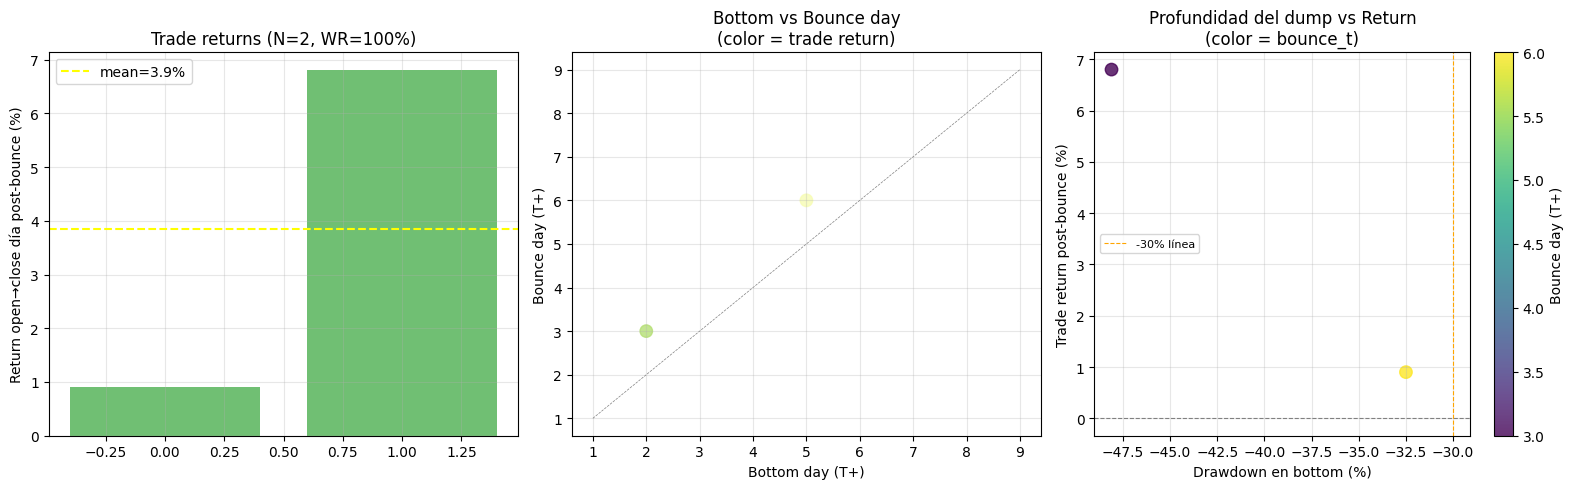

In [178]:
# ── 10d. Visualización ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: distribución de trade_ret
if len(tradeable) > 0:
    colors = ['#4caf50' if r > 0 else '#f44336' for r in sorted(tradeable['trade_ret'])]
    axes[0].bar(range(len(tradeable)), sorted(tradeable['trade_ret'])*100 if False else
                [r*100 for r in sorted(tradeable['trade_ret'])], color=colors, alpha=0.8)
    axes[0].axhline(0, color='white', linewidth=0.8)
    axes[0].axhline(mean*100, color='yellow', linewidth=1.5, linestyle='--', label=f'mean={mean:.1%}')
    axes[0].set_title(f'Trade returns (N={n}, WR={wr:.0%})')
    axes[0].set_ylabel('Return open→close día post-bounce (%)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Plot 2: bottom_t vs bounce_t scatter
bt_valid = bt[bt['bounce_found']].copy()
if len(bt_valid) > 0:
    axes[1].scatter(bt_valid['bottom_t'], bt_valid['bounce_t'],
                    c=bt_valid['trade_ret'].fillna(0)*100,
                    cmap='RdYlGn', s=80, alpha=0.8, vmin=-20, vmax=20)
    axes[1].plot([1,9],[1,9], 'gray', linewidth=0.5, linestyle='--')
    axes[1].set_xlabel('Bottom day (T+)')
    axes[1].set_ylabel('Bounce day (T+)')
    axes[1].set_title('Bottom vs Bounce day\n(color = trade return)')
    axes[1].set_xticks(range(1,10))
    axes[1].set_yticks(range(1,10))
    axes[1].grid(True, alpha=0.3)

# Plot 3: drawdown depth vs trade return
if len(tradeable) > 0:
    sc = axes[2].scatter(tradeable['bottom_ret']*100, tradeable['trade_ret']*100,
                         c=tradeable['bounce_t'], cmap='viridis', s=80, alpha=0.8)
    axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[2].axvline(-30, color='orange', linewidth=0.8, linestyle='--', label='-30% línea')
    axes[2].set_xlabel('Drawdown en bottom (%)')
    axes[2].set_ylabel('Trade return post-bounce (%)')
    axes[2].set_title('Profundidad del dump vs Return\n(color = bounce_t)')
    axes[2].legend(fontsize=8)
    plt.colorbar(sc, ax=axes[2], label='Bounce day (T+)')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. ¿Cómo integrar esto en el scanner?

Si el backtest muestra edge, el flujo sería:

```
Finviz captura ticker en Top Gainers ≥38% del día
    → Guardar en tabla 'finviz_bursts' con burst_date y burst_high
    → Los días siguientes, al cierre de mercado, comprobar:
        - cum_ret desde burst_high ≤ -20% (ha colapsado suficiente)
        - día actual: body_pct > 0 AND close_pos > 0.5 (primer verde fuerte)
    → Si cumple: añadir a proactive_candidates como 'FINVIZ_BOUNCE'
    → Sistema entra al open del día siguiente
```

**Ventaja vs PBT1 actual:**
- Universo de tickers ya filtrado (bursts reales de Finviz, no detección IBKR)
- La caída del -20-35% reduce el riesgo absoluto
- El short-covering crea momentum real el día del bounce
- No depende de quality scores ni EV grades que mostraron correlación inversa


## 12. Multi-Day Momentum — Patrón A

**Hipótesis:** Un ticker que aparece en Top Gainers en días de mercado **consecutivos** (no solo snapshots del mismo día)
muestra momentum sostenido, no un pump de un día. ¿Qué hace el día N+1 después de N días consecutivos en la lista?

**Diferencia clave vs análisis anterior:**
- Antes: burst = muchos snapshots en UN día → colapso -21%
- Ahora: momentum = aparece en Top Gainers en DÍA 1 Y DÍA 2 Y DÍA 3... → ¿continúa o revierte?

El volumen acumulado durante los días de momentum es la señal de confirmación.


In [179]:
# ── 12a. Parsear volumen + presencia diaria ──
import sqlite3, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as scipy_stats

DB_FV = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'

def parse_volume(v):
    if pd.isna(v) or str(v).strip() in ('', '0'):
        return np.nan
    v = str(v).strip().upper().replace(',', '')
    try:
        if v.endswith('M'):   return float(v[:-1]) * 1_000_000
        elif v.endswith('K'): return float(v[:-1]) * 1_000
        elif v.endswith('B'): return float(v[:-1]) * 1_000_000_000
        else:                 return float(v)
    except:
        return np.nan

conn = sqlite3.connect(DB_FV)
raw = pd.read_sql('SELECT * FROM snapshots ORDER BY timestamp', conn)
conn.close()

raw['ts']        = pd.to_datetime(raw['timestamp'], utc=True).dt.tz_convert('US/Eastern')
raw['date']      = raw['ts'].dt.date
raw['snap']      = raw['ts'].dt.floor('15min')
raw['chg']       = pd.to_numeric(raw['change_pct'].str.replace('%','',regex=False), errors='coerce')
raw['price_num'] = pd.to_numeric(raw['price'], errors='coerce')
raw['vol_num']   = raw['volume'].apply(parse_volume)

# Solo Top Gainers
tg = raw[raw['category'] == 'Top Gainers'].copy()

# Total snapshots por día (del universo Top Gainers)
snaps_per_day = tg.groupby('date')['snap'].nunique().rename('day_total_snaps')

# Presencia diaria por ticker — sin lambda complejo
daily = tg.groupby(['ticker','date']).agg(
    n_snaps    = ('snap',      'nunique'),
    avg_chg    = ('chg',       'mean'),
    max_chg    = ('chg',       'max'),
    avg_price  = ('price_num', 'mean'),
    last_price = ('price_num', 'last'),
    avg_vol    = ('vol_num',   'mean'),
    max_vol    = ('vol_num',   'max'),
).reset_index()

# Merge con total snaps del día
daily = daily.merge(snaps_per_day.reset_index(), on='date')
daily['presence_pct'] = daily['n_snaps'] / daily['day_total_snaps']
daily['in_list']      = daily['presence_pct'] >= 0.20

print(f'Días únicos: {daily["date"].nunique()}')
print(f'Tickers únicos en Top Gainers: {daily["ticker"].nunique()}')
print()
print('Tickers en lista por día:')
for d in sorted(daily['date'].unique()):
    n = daily[(daily['date']==d) & daily['in_list']]['ticker'].nunique()
    snaps = snaps_per_day.get(d, 0)
    print(f'  {d}: {n:3d} tickers  ({snaps} snaps ese día)')


Días únicos: 11
Tickers únicos en Top Gainers: 113

Tickers en lista por día:
  2026-03-24:   9 tickers  (26 snaps ese día)
  2026-03-25:   9 tickers  (25 snaps ese día)
  2026-03-26:   8 tickers  (25 snaps ese día)
  2026-03-27:   8 tickers  (26 snaps ese día)
  2026-03-30:   8 tickers  (26 snaps ese día)
  2026-04-01:   8 tickers  (9 snaps ese día)
  2026-04-02:   9 tickers  (26 snaps ese día)
  2026-04-06:  10 tickers  (26 snaps ese día)
  2026-04-07:   9 tickers  (26 snaps ese día)
  2026-04-08:   9 tickers  (26 snaps ese día)
  2026-04-09:   9 tickers  (12 snaps ese día)


In [180]:
# ── 12b. Detectar racha de días consecutivos por ticker ──
from datetime import timedelta

all_days = sorted(daily['date'].unique())
day_idx  = {d: i for i, d in enumerate(all_days)}

# Para cada ticker-día, calcular cuántos días consecutivos lleva en la lista
streaks = []
for ticker, grp in daily[daily['in_list']].groupby('ticker'):
    grp = grp.sort_values('date').reset_index(drop=True)
    streak = 1
    for i, row in grp.iterrows():
        if i == 0:
            streak = 1
        else:
            prev_date = grp.loc[i-1, 'date']
            curr_date = row['date']
            # ¿Son días de mercado consecutivos?
            prev_idx = day_idx.get(prev_date, -99)
            curr_idx = day_idx.get(curr_date, -99)
            if curr_idx - prev_idx == 1:
                streak += 1
            else:
                streak = 1
        streaks.append({
            'ticker':       ticker,
            'date':         row['date'],
            'streak':       streak,          # días consecutivos hasta hoy inclusive
            'n_snaps':      row['n_snaps'],
            'presence_pct': row['presence_pct'],
            'avg_chg':      row['avg_chg'],
            'avg_price':    row['avg_price'],
            'last_price':   row['last_price'],
            'avg_vol':      row['avg_vol'],
            'max_vol':      row['max_vol'],
        })

streak_df = pd.DataFrame(streaks)

print('Distribución de rachas (días consecutivos en Top Gainers):')
print(streak_df['streak'].value_counts().sort_index().to_string())
print()
print('Tickers con racha >= 2 días:')
multi = streak_df[streak_df['streak'] >= 2].sort_values(['streak','date'], ascending=[False,False])
print(multi[['ticker','date','streak','presence_pct','avg_chg','avg_vol']].to_string(index=False))


Distribución de rachas (días consecutivos en Top Gainers):
streak
1    91
2     5

Tickers con racha >= 2 días:
ticker       date  streak  presence_pct  avg_chg      avg_vol
  ELAB 2026-04-09       2          0.25    38.55  38063333.33
  MGRT 2026-04-09       2          0.42    28.57     63092.50
  AIXI 2026-04-07       2          1.00   123.24 384135600.00
  ELAB 2026-04-01       2          0.33    87.70  29746666.67
  MKDW 2026-03-25       2          0.72    40.28   1216271.76


In [181]:
# ── 12c. Forward return: ¿qué hace el ticker el día siguiente a N días consecutivos? ──
# Usamos el cache de precios IBKR para el forward return

prices = pd.read_csv(CACHE_FILE, parse_dates=['date'])
prices['date'] = prices['date'].dt.date
prices = prices.sort_values(['symbol','date'])
price_idx = prices.set_index(['symbol','date'])

def get_next_trading_day(date, all_days):
    future = [d for d in all_days if d > date]
    return future[0] if future else None

all_trading_days_prices = sorted(prices['date'].unique())

# Merge candle quality en streak_df (desde price cache)
_px2 = prices.set_index(['symbol','date']) if 'prices' in dir() else None

def _get_candle(ticker, date):
    if _px2 is None:
        return {}
    key = (ticker, date)
    if key not in _px2.index:
        return {}
    b = _px2.loc[key]
    o, h, l, c = b['open'], b['high'], b['low'], b['close']
    body = c - o
    uw   = h - max(o,c)
    rng  = h - l
    return {
        'candle_green':     c > o,
        'upper_wick_ratio': uw / abs(body) if abs(body) > 0 else np.nan,
        'burst_close_pos':  (c-l)/rng if rng > 0 else np.nan,
    }

# Filtros aplicables al streak analysis
STREAK_REQUIRE_GREEN  = True
STREAK_MAX_WICK_RATIO = 1.0

fwd_rows = []
for _, row in streak_df.iterrows():
    cq = _get_candle(row['ticker'], row['date'])
    if STREAK_REQUIRE_GREEN and not cq.get('candle_green', False):
        continue
    if STREAK_MAX_WICK_RATIO is not None:
        wr_c = cq.get('upper_wick_ratio', np.nan)
        if pd.isna(wr_c) or wr_c > STREAK_MAX_WICK_RATIO:
            continue
    ticker = row['ticker']
    date   = row['date']
    streak = row['streak']

    # Día siguiente
    next_day = get_next_trading_day(date, all_trading_days_prices)
    if next_day is None:
        continue

    # Necesitamos precio de cierre de HOY y open+close de mañana
    try:
        today_close = price_idx.loc[(ticker, date), 'close']
        next_open   = price_idx.loc[(ticker, next_day), 'open']
        next_close  = price_idx.loc[(ticker, next_day), 'close']
        next_high   = price_idx.loc[(ticker, next_day), 'high']
        next_low    = price_idx.loc[(ticker, next_day), 'low']
    except KeyError:
        continue

    if pd.isna(today_close) or pd.isna(next_open) or today_close == 0:
        continue

    gap_pct      = (next_open / today_close - 1) * 100
    day_ret      = (next_close / next_open - 1) * 100   # open→close (ejecutable)
    overnight    = (next_open / today_close - 1) * 100  # gap overnight
    full_ret     = (next_close / today_close - 1) * 100 # close→close

    rng = next_high - next_low
    cp  = (next_close - next_low) / rng if rng > 0 else np.nan

    fwd_rows.append({
        'ticker':    ticker,
        'signal_date': date,
        'next_date': next_day,
        'streak':    streak,
        'avg_vol':   row['avg_vol'],
        'avg_chg':   row['avg_chg'],
        'gap_pct':   round(gap_pct, 2),
        'day_ret':   round(day_ret, 2),      # open→close día siguiente
        'full_ret':  round(full_ret, 2),     # close→close
        'close_pos': round(cp, 3) if not pd.isna(cp) else np.nan,
    })

fwd = pd.DataFrame(fwd_rows)
print(f'Observaciones con forward return: {len(fwd)}')
print()
print('Por racha (streak):')
for s in sorted(fwd['streak'].unique()):
    sub = fwd[fwd['streak'] == s]
    wr  = (sub['day_ret'] > 0).mean()
    mn  = sub['day_ret'].mean()
    md  = sub['day_ret'].median()
    n   = len(sub)
    print(f'  streak={s}: N={n:3d}, WR={wr:.0%}, mean={mn:+.1f}%, median={md:+.1f}%')


Observaciones con forward return: 31

Por racha (streak):
  streak=1: N= 28, WR=54%, mean=+8.5%, median=+0.7%
  streak=2: N=  3, WR=67%, mean=+14.7%, median=+9.4%


In [182]:
# ── 12d. Test estadístico por racha + filtros de volumen ──
print('=' * 60)
print('EDGE POR NÚMERO DE DÍAS CONSECUTIVOS EN TOP GAINERS')
print('=' * 60)
print()

for s in sorted(fwd['streak'].unique()):
    sub = fwd[fwd['streak'] == s]['day_ret'].dropna()
    if len(sub) < 3:
        continue
    wr = (sub > 0).mean()
    mn = sub.mean()
    md = sub.median()
    k  = (sub > 0).sum()
    n  = len(sub)
    binom = scipy_stats.binomtest(k, n, 0.5, alternative='greater')
    ttest = scipy_stats.ttest_1samp(sub, 0)
    sig = '*** p<0.05' if binom.pvalue < 0.05 else ('~ p<0.15' if binom.pvalue < 0.15 else '')
    print(f'streak={s}: N={n:3d} | WR={wr:.0%} | mean={mn:+.1f}% | median={md:+.1f}% | p={binom.pvalue:.3f} {sig}')

print()
print('─' * 60)
print('FILTRO ADICIONAL: volumen alto (avg_vol > percentil 75 del día)')
print('─' * 60)

vol_p75 = fwd['avg_vol'].quantile(0.75)
print(f'Percentil 75 de volumen: {vol_p75:,.0f}')
print()
for s in sorted(fwd['streak'].unique()):
    sub_all = fwd[fwd['streak'] == s]
    sub_vol = sub_all[sub_all['avg_vol'] > vol_p75]['day_ret'].dropna()
    if len(sub_vol) < 3:
        continue
    wr = (sub_vol > 0).mean()
    mn = sub_vol.mean()
    n  = len(sub_vol)
    k  = (sub_vol > 0).sum()
    binom = scipy_stats.binomtest(k, n, 0.5, alternative='greater')
    sig = '*** p<0.05' if binom.pvalue < 0.05 else ('~ p<0.15' if binom.pvalue < 0.15 else '')
    print(f'streak={s} + vol alto: N={n:3d} | WR={wr:.0%} | mean={mn:+.1f}% | p={binom.pvalue:.3f} {sig}')


EDGE POR NÚMERO DE DÍAS CONSECUTIVOS EN TOP GAINERS

streak=1: N= 28 | WR=54% | mean=+8.5% | median=+0.7% | p=0.425 
streak=2: N=  3 | WR=67% | mean=+14.7% | median=+9.4% | p=0.500 

────────────────────────────────────────────────────────────
FILTRO ADICIONAL: volumen alto (avg_vol > percentil 75 del día)
────────────────────────────────────────────────────────────
Percentil 75 de volumen: 74,959,311

streak=1 + vol alto: N=  7 | WR=71% | mean=+20.7% | p=0.227 


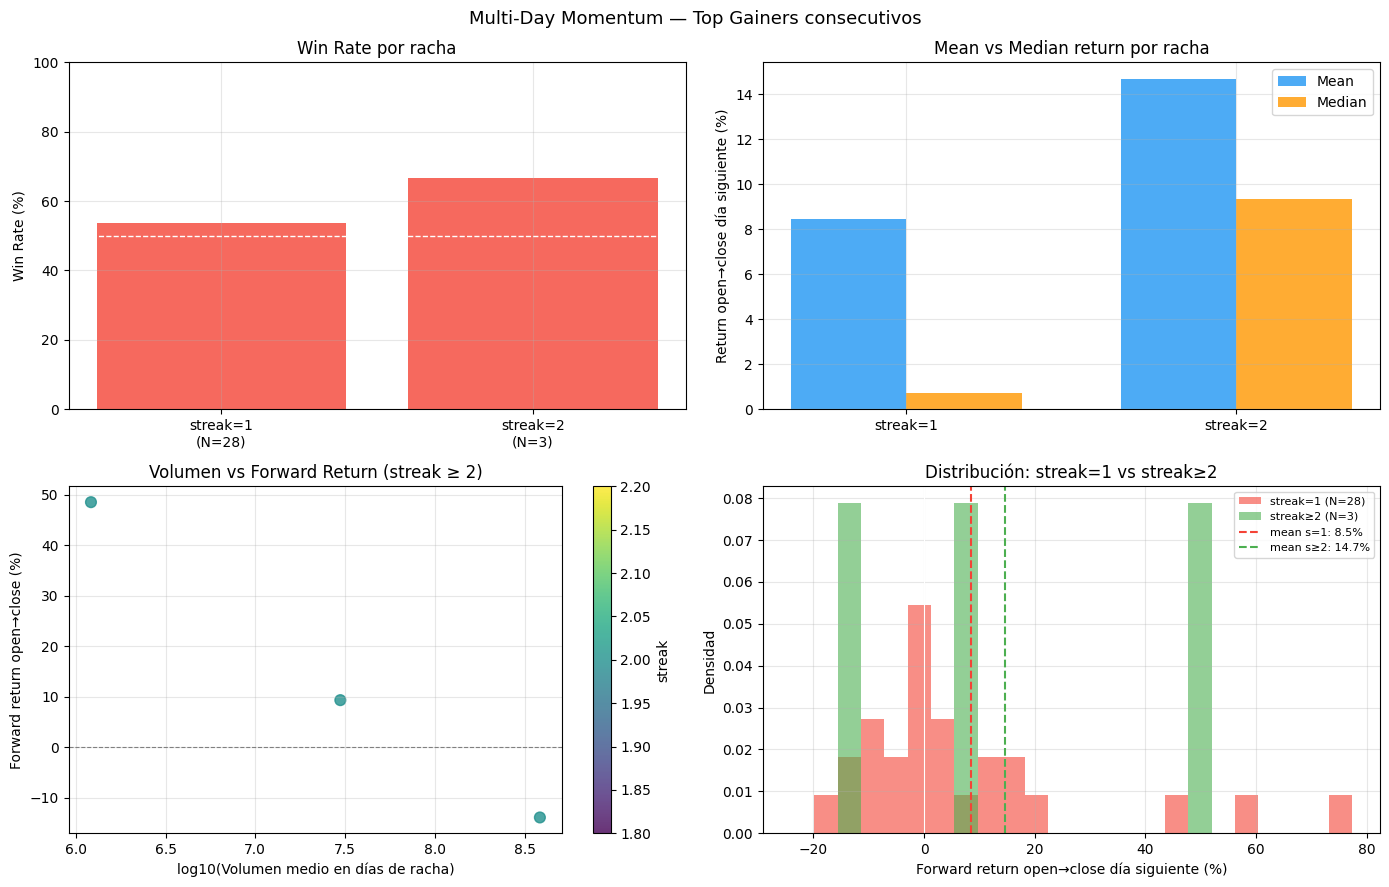

In [183]:
# ── 12e. Visualización ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Multi-Day Momentum — Top Gainers consecutivos', fontsize=13)

streaks_available = sorted(fwd['streak'].unique())

# Plot 1: WR y mean por streak
wr_by_streak   = fwd.groupby('streak')['day_ret'].apply(lambda x: (x>0).mean())
mean_by_streak = fwd.groupby('streak')['day_ret'].mean()
med_by_streak  = fwd.groupby('streak')['day_ret'].median()
n_by_streak    = fwd.groupby('streak').size()

ax = axes[0,0]
x = list(wr_by_streak.index)
ax.bar(x, wr_by_streak.values * 100, color=['#4caf50' if w > 50 else '#f44336' for w in wr_by_streak.values], alpha=0.8)
ax.axhline(50, color='white', linewidth=1, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([f'streak={s}\n(N={n_by_streak[s]})' for s in x])
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate por racha')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# Plot 2: mean y median por streak
ax = axes[0,1]
w = 0.35
ax.bar([xi-w/2 for xi in range(len(x))], mean_by_streak.values, width=w, label='Mean', color='#2196F3', alpha=0.8)
ax.bar([xi+w/2 for xi in range(len(x))], med_by_streak.values, width=w, label='Median', color='#ff9800', alpha=0.8)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_xticks(range(len(x)))
ax.set_xticklabels([f'streak={s}' for s in x])
ax.set_ylabel('Return open→close día siguiente (%)')
ax.set_title('Mean vs Median return por racha')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: scatter volumen vs forward return (streak >= 2)
ax = axes[1,0]
sub = fwd[fwd['streak'] >= 2].dropna(subset=['avg_vol','day_ret'])
if len(sub) > 0:
    sc = ax.scatter(np.log10(sub['avg_vol'].clip(lower=1)), sub['day_ret'],
                    c=sub['streak'], cmap='viridis', s=60, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlabel('log10(Volumen medio en días de racha)')
    ax.set_ylabel('Forward return open→close (%)')
    ax.set_title('Volumen vs Forward Return (streak ≥ 2)')
    plt.colorbar(sc, ax=ax, label='streak')
    ax.grid(True, alpha=0.3)

# Plot 4: distribución de returns para streak=1 vs streak>=2
ax = axes[1,1]
s1  = fwd[fwd['streak'] == 1]['day_ret'].dropna()
s2p = fwd[fwd['streak'] >= 2]['day_ret'].dropna()
bins = np.linspace(fwd['day_ret'].quantile(0.02), fwd['day_ret'].quantile(0.98), 25)
ax.hist(s1,  bins=bins, alpha=0.6, label=f'streak=1 (N={len(s1)})',  color='#f44336', density=True)
ax.hist(s2p, bins=bins, alpha=0.6, label=f'streak≥2 (N={len(s2p)})', color='#4caf50', density=True)
ax.axvline(0, color='white', linewidth=0.8)
ax.axvline(s1.mean(),  color='#f44336', linewidth=1.5, linestyle='--', label=f'mean s=1: {s1.mean():.1f}%')
ax.axvline(s2p.mean(), color='#4caf50', linewidth=1.5, linestyle='--', label=f'mean s≥2: {s2p.mean():.1f}%')
ax.set_xlabel('Forward return open→close día siguiente (%)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución: streak=1 vs streak≥2')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [184]:
# ── 12f. Detalle: los trades con streak >= 2 ──
print('Detalle de señales con streak >= 2:')
print()
cols = ['ticker','signal_date','next_date','streak','avg_vol','avg_chg','gap_pct','day_ret','close_pos']
multi_fwd = fwd[fwd['streak'] >= 2].sort_values('day_ret', ascending=False)
pd.set_option('display.float_format', '{:.2f}'.format)
print(multi_fwd[cols].to_string(index=False))
print()

# Resumen ejecutivo
if len(multi_fwd) > 0:
    print('─' * 50)
    print('RESUMEN EJECUTIVO — streak >= 2')
    print('─' * 50)
    wr  = (multi_fwd['day_ret'] > 0).mean()
    mn  = multi_fwd['day_ret'].mean()
    md  = multi_fwd['day_ret'].median()
    n   = len(multi_fwd)
    k   = (multi_fwd['day_ret'] > 0).sum()
    if n >= 3:
        binom = scipy_stats.binomtest(k, n, 0.5, alternative='greater')
        ttest = scipy_stats.ttest_1samp(multi_fwd['day_ret'].dropna(), 0)
        print(f'N: {n}  |  WR: {wr:.1%}  |  Mean: {mn:+.1f}%  |  Median: {md:+.1f}%')
        print(f'Binomial p: {binom.pvalue:.4f}  |  t-test p: {ttest.pvalue:.4f}')


Detalle de señales con streak >= 2:

ticker signal_date  next_date  streak      avg_vol  avg_chg  gap_pct  day_ret  close_pos
  MKDW  2026-03-25 2026-03-26       2   1216271.76    40.28     0.38    48.57       1.00
  ELAB  2026-04-01 2026-04-02       2  29746666.67    87.70   -62.64     9.37       0.46
  AIXI  2026-04-07 2026-04-08       2 384135600.00   123.24   -14.87   -13.86       0.50

──────────────────────────────────────────────────
RESUMEN EJECUTIVO — streak >= 2
──────────────────────────────────────────────────
N: 3  |  WR: 66.7%  |  Mean: +14.7%  |  Median: +9.4%
Binomial p: 0.5000  |  t-test p: 0.5046


## 13. Universo SHORT — Bursts con vela roja

Los bursts que cerraron en rojo el burst day son candidatos a SHORT.
Ya demostramos que T+1 tras un burst tiene WR=17% para longs → WR=83% para shorts.
Aquí analizamos específicamente los bursts rojos: ¿son aún mejores candidatos a short?

**Lógica:** Vela roja en burst day = los vendedores ya tomaron el control el mismo día del burst.
La distribución ya empezó. Short entry en T+1 open.


In [188]:
# ── 13a. Dataset SHORT: T+1..T+9 para bursts con vela roja ──

# Redefinir get_trading_day localmente (evita problema de scope con 'date')
def _get_td(ref_date, offset, trading_days):
    ref = pd.Timestamp(ref_date).date() if hasattr(ref_date, 'hour') else ref_date
    future = [d for d in trading_days if d > ref]
    return future[offset - 1] if len(future) >= offset else None

records_short = []
for _, burst in persist_short.iterrows():
    ticker     = burst['ticker']
    burst_date = pd.Timestamp(burst['burst_date']).date()

    sym_prices = prices[prices['symbol'] == ticker].set_index('date')
    if sym_prices.empty or burst_date not in sym_prices.index:
        continue

    burst_bar = sym_prices.loc[burst_date]
    trigger   = burst_bar['high']

    bo, bh, bl, bc = burst_bar['open'], burst_bar['high'], burst_bar['low'], burst_bar['close']
    body = bc - bo
    rng  = bh - bl
    uw   = bh - max(bo, bc)

    row = {
        'ticker':           ticker,
        'burst_date':       burst_date,
        'n_snaps':          burst['n_snaps'],
        'burst_chg':        round(burst['burst_chg'], 1),
        'burst_open':       bo, 'burst_high': bh,
        'burst_low':        bl, 'burst_close': bc,
        'candle_body_pct':  round(body/bo*100, 1) if bo > 0 else np.nan,
        'upper_wick_ratio': round(uw/abs(body), 2) if abs(body) > 0 else np.nan,
        'burst_close_pos':  round((bc-bl)/rng, 2) if rng > 0 else np.nan,
    }

    for t in range(1, 10):
        td = _get_td(burst_date, t, all_trading_days)
        if td is None or td not in sym_prices.index:
            row[f'T{t}_ret'] = None
            continue
        bar = sym_prices.loc[td]
        # SHORT: retorno = inverso (si precio baja, short gana)
        short_ret = (burst_bar['close'] / bar['close'] - 1) * 100  # short entry=burst_close, exit=T close
        row[f'T{t}_ret_short'] = round(short_ret, 2)
        row[f'T{t}_ret_long']  = round((bar['close'] / trigger - 1) * 100, 2)  # para comparar

    records_short.append(row)

results_short = pd.DataFrame(records_short)
print(f'Bursts SHORT con datos: {len(results_short)} / {len(persist_short)}')
print()

# Stats básicas
print(f'{"T":>3}  {"N":>4}  {"WR_short":>9}  {"Mean_short":>11}  {"Median_short":>13}')
print('-' * 45)
for t in range(1, 10):
    col = f'T{t}_ret_short'
    if col not in results_short.columns:
        continue
    data = results_short[col].dropna()
    if len(data) < 3:
        continue
    wr   = (data > 0).mean()
    mean = data.mean()
    med  = data.median()
    print(f'T+{t}  {len(data):>4}  {wr:>9.0%}  {mean:>+11.1f}%  {med:>+13.1f}%')


Bursts SHORT con datos: 22 / 22

  T     N   WR_short   Mean_short   Median_short
---------------------------------------------
T+1    19        74%        +10.7%          +10.7%
T+2    17        71%        +12.7%          +15.4%
T+3    14        71%        +21.4%           +9.2%
T+4    11        73%        +22.7%           +7.0%
T+5     8        88%        +29.8%          +15.2%
T+6     8        75%        +36.0%          +34.0%
T+7     8        75%        +50.3%          +46.9%
T+8     6       100%        +66.4%          +44.0%
T+9     4       100%        +68.4%          +46.4%


In [ ]:
# ── 13b. Comparación: SHORT roja vs LONG verde en T+1 ──
from scipy import stats as scipy_stats

print('=' * 60)
print('COMPARACIÓN: Short (burst rojo) vs Long (burst verde) en T+1')
print('=' * 60)
print()

# SHORT universe
s_data = results_short['T1_ret_short'].dropna() if 'T1_ret_short' in results_short.columns else pd.Series()
# LONG universe
l_data = results['T1_ret'].dropna() if 'T1_ret' in results.columns else pd.Series()

for label, data, direction in [
    ('SHORT burst rojo (entry T+1 open, exit T+1 close)', s_data, 'short'),
    ('LONG  burst verde (entry=trigger, ret T+1 close)',   l_data, 'long'),
]:
    if len(data) < 3:
        print(f'{label}: N insuficiente ({len(data)})')
        continue
    wr   = (data > 0).mean()
    mean = data.mean()
    med  = data.median()
    n    = len(data)
    k    = (data > 0).sum()
    bp   = scipy_stats.binomtest(k, n, 0.5, alternative='greater').pvalue
    tp   = scipy_stats.ttest_1samp(data, 0).pvalue
    sig  = '*** p<0.05' if bp < 0.05 else ('~ p<0.15' if bp < 0.15 else '')
    print(f'{label}')
    print(f'  N={n}, WR={wr:.0%}, Mean={mean:+.1f}%, Median={med:+.1f}%, p_binom={bp:.4f} {sig}')
    print()


In [189]:
# ── 13c. Filtros adicionales para SHORT: mecha y close_pos ──
# Bursts rojos con mecha grande arriba son aún más bajistas (rechazo del precio)
r_s = results_short.copy()

short_filters = [
    ('Sin filtros (todos rojos)',              r_s),
    ('Mecha > 1x cuerpo (rechazo fuerte)',     r_s[r_s['upper_wick_ratio'] > 1.0]),
    ('Mecha > 2x cuerpo (rechazo extremo)',    r_s[r_s['upper_wick_ratio'] > 2.0]),
    ('close_pos < 0.30 (cerró en mínimos)',    r_s[r_s['burst_close_pos'] < 0.30]),
    ('Mecha>1x + close_pos<0.30',              r_s[(r_s['upper_wick_ratio'] > 1.0) & (r_s['burst_close_pos'] < 0.30)]),
]

col = 'T1_ret_short'
print(f'{"Filtro SHORT":45s}  {"n":>4}  {"WR":>6}  {"Mean":>8}  {"p":>7}')
print('-' * 80)
for name, subset in short_filters:
    data = subset[col].dropna() if col in subset.columns else pd.Series()
    if len(data) < 3:
        print(f'{name:45s}  {len(subset):>4}  (N insuficiente)')
        continue
    wr   = (data > 0).mean()
    mean = data.mean()
    k    = (data > 0).sum()
    n    = len(data)
    bp   = scipy_stats.binomtest(k, n, 0.5, alternative='greater').pvalue
    sig  = '*** p<0.05' if bp < 0.05 else ('~ p<0.15' if bp < 0.15 else '')
    print(f'{name:45s}  {n:>4}  {wr:>6.0%}  {mean:>+8.1f}%  {bp:>7.4f} {sig}')


Filtro SHORT                                      n      WR      Mean        p
--------------------------------------------------------------------------------
Sin filtros (todos rojos)                        19     74%     +10.7%   0.0318 *** p<0.05
Mecha > 1x cuerpo (rechazo fuerte)               11     73%     +16.0%   0.1133 ~ p<0.15
Mecha > 2x cuerpo (rechazo extremo)               6     83%     +22.3%   0.1094 ~ p<0.15
close_pos < 0.30 (cerró en mínimos)              17     71%     +11.5%   0.0717 ~ p<0.15
Mecha>1x + close_pos<0.30                        11     73%     +16.0%   0.1133 ~ p<0.15
